In [15]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

# Imports y configuraciones basicas
import os
import ast
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

# ==========================================
# CONFIGURACIONES GLOBALES
# ==========================================
sns.set_style("whitegrid") 
# from src.config import crear_directorios_overleaf
# crear_directorios_overleaf()  # Crea subcarpetas en graficos_overleaf/

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# CARGA Y LIMPIEZA DE DATOS (Nomenclatura completa)
# ==========================================
df_base = pd.read_excel("../data/pacientes.xlsx")
hospitales = pd.read_csv("../data/hospitales_coordenadas.csv")

# Diccionarios de referencia para hospitales
dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
hospitales['color_rgb'] = hospitales['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# --- RECUPERADO: El renombre COMPLETO de columnas ---
df_base = df_base.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',
    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',
    'Sexo': 'sexo',
    'Edad': 'edad',
    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',
    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',
    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',
    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',
    'Asistencia Respiratoria Mecánica': 'requiere_arm',
    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',
    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',
    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

df_base['hospital_origen'] = df_base['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

df_base['fecha_ingreso'] = pd.to_datetime(df_base['fecha_ingreso'], errors='coerce')
df_base['fecha_egreso'] = pd.to_datetime(df_base['fecha_egreso'], errors='coerce')
df_base = df_base.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. MÉTRICAS DE TRAYECTORIA DEL PACIENTE (RED)
# ==========================================
# Agrupamos por paciente para extraer el inicio, fin y los motivos
df_metricas_globales = df_base.groupby('paciente_id').agg(
    fecha_ingreso_red=('fecha_ingreso', 'first'),  
    fecha_egreso_red=('fecha_egreso', 'last'),     
    motivos_historial=('motivo_egreso', list),     
    motivo_fin_caso=('motivo_egreso', 'last')      
).reset_index()

# Validamos que el motivo de fin de caso
condiciones = [
    df_metricas_globales['motivo_fin_caso'] == 'alta-domiciliaria',
    df_metricas_globales['motivo_fin_caso'] == 'muerte',
    df_metricas_globales['motivo_fin_caso'] == 'traslado-otro',
    df_metricas_globales['motivo_fin_caso'] == 'traslado-extra-sanitario'
]
resultados = ['alta', 'muerte', 'hospital externo', 'alta hotel']

df_metricas_globales['motivo_fin_caso'] = np.select(condiciones, resultados, default='otro/desconocido')
df_base = df_base.merge(df_metricas_globales, on='paciente_id', how='left')


# ==========================================
# 3. CORE DEL MODELO: CONSTRUCCIÓN DE TRASLADOS (PARA MAPAS)
# ==========================================
df_base['hospital_destino'] = df_base.groupby('paciente_id')['hospital_origen'].shift(-1)
df_base['fecha_ingreso_destino'] = df_base.groupby('paciente_id')['fecha_ingreso'].shift(-1)
df_base['estado_destino'] = df_base.groupby('paciente_id')['estado_ingreso'].shift(-1)
df_base['tipo_destino'] = df_base.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

df_base['dias_traslado'] = (df_base['fecha_ingreso_destino'] - df_base['fecha_egreso']).dt.days
df_base.loc[df_base['dias_traslado'] == -1, 'dias_traslado'] = 0

motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']
mask_traslados = (
    df_base['hospital_destino'].notna() & 
    df_base['motivo_egreso'].isin(motivos_validos) & 
    (df_base['hospital_origen'] != df_base['hospital_destino'])
)

df_potenciales = df_base[mask_traslados].copy() 
df_aristas_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_aristas_traslados = df_aristas_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})

df_aristas_traslados['alerta_demora'] = df_aristas_traslados['dias_traslado'] > 3
df_aristas_traslados['dias_alerta'] = df_aristas_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# ==========================================
# 4. TABLAS RELACIONALES: ESTANCIAS Y TRAYECTORIAS
# ==========================================
# A. Armamos las Estancias (Episodios) sin perder el último destino
df_estancias_episodios = df_base.sort_values(['paciente_id', 'fecha_ingreso']).copy()
df_estancias_episodios['orden_episodio'] = df_estancias_episodios.groupby('paciente_id').cumcount() + 1
df_estancias_episodios['dias_en_nodo'] = (df_estancias_episodios['fecha_egreso'] - df_estancias_episodios['fecha_ingreso']).dt.days

# Pegamos la complejidad a cada internación
df_estancias_episodios = df_estancias_episodios.merge(
    hospitales[['Nombre Hospital', 'complejidad']], 
    left_on='hospital_origen', right_on='Nombre Hospital', how='left'
)
df_estancias_episodios['nivel_complejidad'] = df_estancias_episodios['complejidad'].fillna('Desc').astype(str).str.replace('.0', '', regex=False)

# B. Armamos las rutas (Trayectorias)
df_rutas = df_estancias_episodios.groupby('paciente_id').agg(
    ruta_hospitales_str=('hospital_origen', lambda x: ' -> '.join(x.astype(str))),
    ruta_complejidad_str=('nivel_complejidad', lambda x: ' -> '.join(x.astype(str))),
    cantidad_traslados=('hospital_origen', lambda x: len(x) - 1)
).reset_index()

# Unimos con las métricas para tener 1 fila por paciente con su resumen total
df_pacientes_trayectorias = df_metricas_globales.merge(df_rutas, on='paciente_id', how='left')
df_pacientes_trayectorias['dias_estadia_total'] = (df_pacientes_trayectorias['fecha_egreso_red'] - df_pacientes_trayectorias['fecha_ingreso_red']).dt.days
df_pacientes_trayectorias['motivo_fin_caso'] = df_pacientes_trayectorias['motivo_fin_caso'].replace('otro/desconocido', 'alta')


# ==========================================
# 5. EL PEDIDO DE LOS MENTORES: TRAYECTORIAS DE 1 TRASLADO
# ==========================================
# Filtramos solo pacientes con 1 traslado (exactamente 2 pasos/nodos)
df_analisis_rutas = df_pacientes_trayectorias[df_pacientes_trayectorias['cantidad_traslados'] == 1].copy()

# Rescatamos la cantidad de días que pasaron en el "orden_episodio == 1"
tiempo_primer_salto = df_estancias_episodios[df_estancias_episodios['orden_episodio'] == 1][['paciente_id', 'dias_en_nodo']]
tiempo_primer_salto = tiempo_primer_salto.rename(columns={'dias_en_nodo': 'tiempo_hasta_traslado'})

# Unimos la info y armamos el DataFrame final con los nombres declarativos que pidieron
df_tiempos_1_traslado = df_analisis_rutas.merge(tiempo_primer_salto, on='paciente_id', how='left')
df_tiempos_1_traslado = df_tiempos_1_traslado[[
    'ruta_complejidad_str', 
    'motivo_fin_caso', 
    'tiempo_hasta_traslado', 
    'dias_estadia_total'
]].rename(columns={
    'ruta_complejidad_str': 'Tipo de trayectoria',
    'motivo_fin_caso': 'Motivo de egreso',
    'dias_estadia_total': 'Tiempo hasta el egreso (total)'
})


# ==========================================
# 6. PREPARACIÓN DE COORDENADAS (Unificado)
# ==========================================
df_coordenadas = hospitales.rename(columns={'Nombre Hospital': 'hospital', 'Latitud': 'lat', 'Longitud': 'lon'})

# Ajustes manuales unificados
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Desplazar duplicados
nuevas_filas = []
for (lat, lon), group in df_coordenadas.groupby(['lat', 'lon']):
    for i, (_, row) in enumerate(group.iterrows()):
        row_mod = row.copy()
        if i > 0:
            row_mod['lon'] = lon + 0.01   
            row_mod['lat'] = lat + (i * 0.015)  
        nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
hospitales_conocidos = set(df_coordenadas['hospital'])

In [17]:
# PRE-CÁLCULOS GLOBALES (DRY - Don't Repeat Yourself)
# ==========================================
# 1. Filtramos aristas válidas una sola vez para todos los gráficos
mask_val_g = (
    (df_aristas_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & 
    (df_aristas_traslados['hospital_destino'].isin(hospitales_conocidos)) & 
    (df_aristas_traslados['hospital_ingreso'] != df_aristas_traslados['hospital_destino'])
)

# APLICACIÓN DE UMBRALES GLOBALES:
# df_aristas_validas se usará EXCLUSIVAMENTE para visualización de grafos/mapas
df_aristas_validas = df_aristas_traslados[mask_val_g].copy()
conteo_aristas = df_aristas_validas.groupby(['hospital_ingreso', 'hospital_destino']).size()
aristas_a_dibujar = conteo_aristas[conteo_aristas >= UMBRAL_MIN_TRASLADOS_GRAFICO].index

# Solo filtramos para la visualización
df_aristas_visualizacion = df_aristas_validas.set_index(['hospital_ingreso', 'hospital_destino']).loc[aristas_a_dibujar].reset_index()

# 2. Agrupamientos globales compartidos (Basados en el universo descriptivo completo)
traslados_globales_grp = df_aristas_validas.groupby(['hospital_ingreso', 'hospital_destino']).size()
ingresos_globales_ser = df_base[df_base['hospital_origen'].isin(hospitales_conocidos)]['hospital_origen'].value_counts()

max_tras_glob = traslados_globales_grp.max() if not traslados_globales_grp.empty else 1
max_ing_glob = ingresos_globales_ser.max() if not ingresos_globales_ser.empty else 1

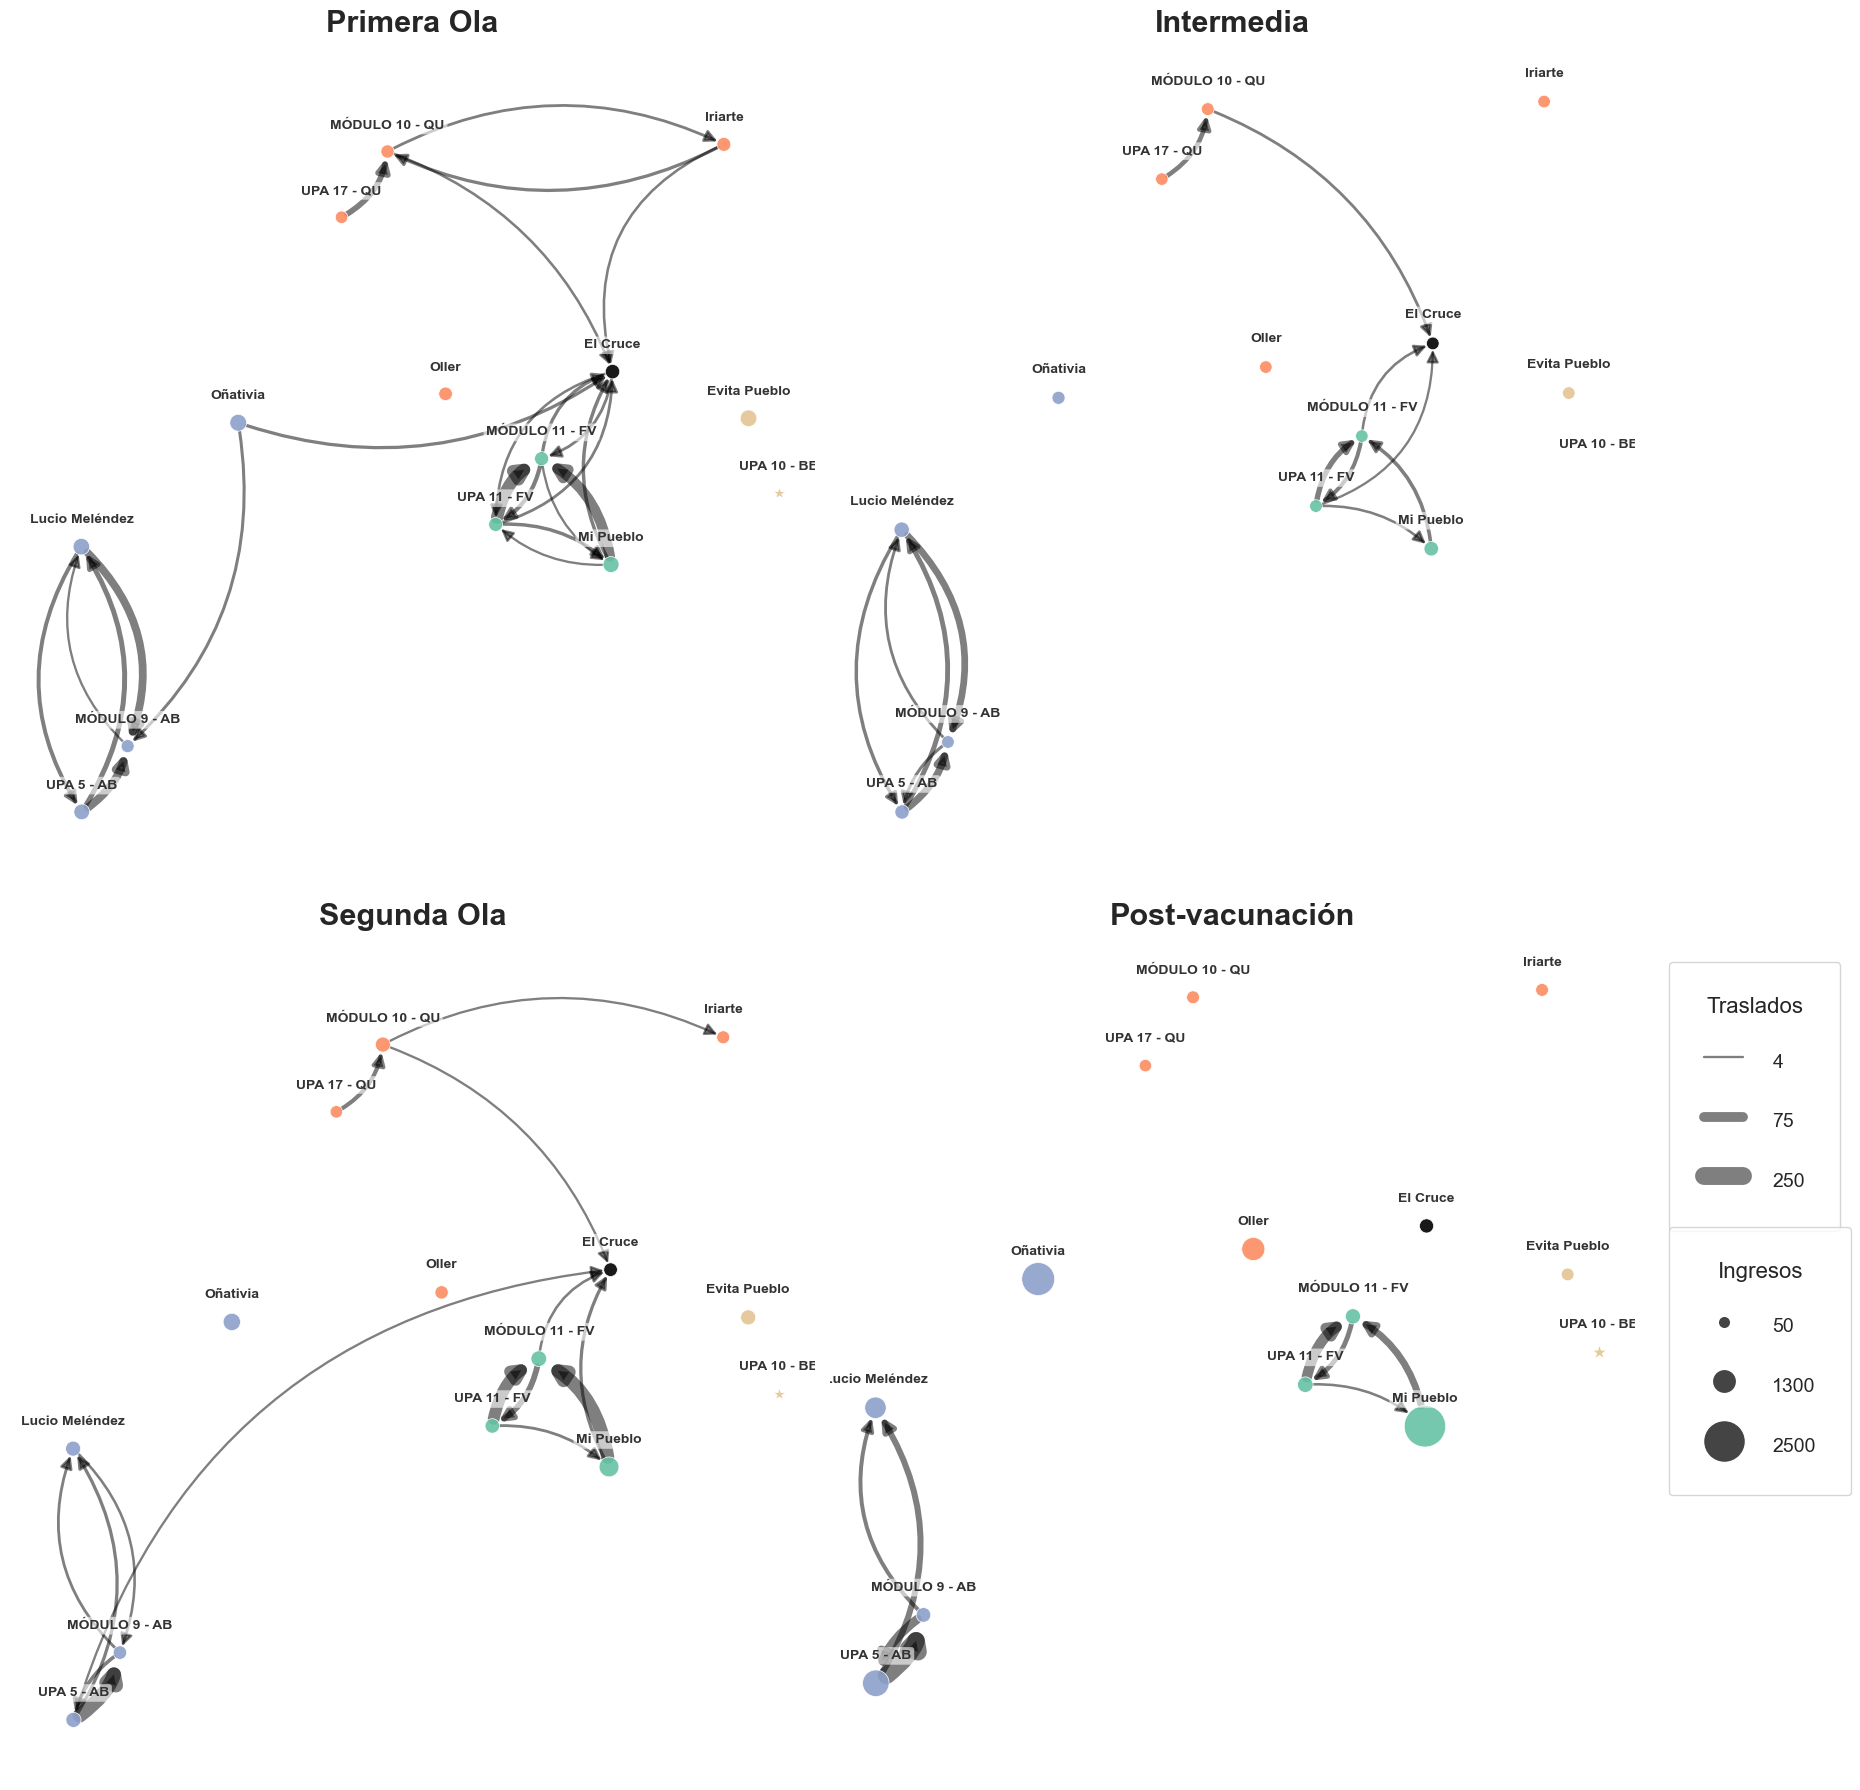

In [18]:
# GRÁFICO 1: GRILLA 2x2 PERIODOS
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.patch.set_facecolor('white')

cfg_grilla = {
    'min_grosor': 0.05, 'max_grosor': 18.0, 'min_tamano': 80, 'max_tamano': 3000, 
    'escala_nodo': 'cuadratica', 'color_por_origen': False, 'aristas_negras': True,
    'alpha_arista': 0.5, 'arrow_size': 18, 'forzar_i_min_50': True,
    'leg_title_sz': 16, 'leg_lbl_sz': 14, 'leg_dynamic_spc': True, 'lbl_size': 10,
    'lbl_weight': 'bold', 'lbl_offset': 0.006, 'lbl_bbox': True, 'lbl_bbox_alpha': 0.6, 'lbl_color': '#333333'
}

v_max_enc, i_max_enc = 0, 0

for idx, (titulo, inicio, fin) in enumerate(PERIODOS):
    ax = axes.flatten()[idx]
    ax.set_title(titulo, fontsize=22, fontweight='bold', pad=20)
    
    # Filtros temporales rápidos
    df_p_per = df_base[df_base['fecha_ingreso'].between(inicio, fin)]
    df_t_per = df_aristas_validas[df_aristas_validas['fecha_egreso'].between(inicio, fin)]
    
    ingresos_ser = df_p_per['hospital_origen'].value_counts()
    traslados_ser = df_t_per.groupby(['hospital_ingreso', 'hospital_destino']).size()
    traslados_dib = traslados_ser[traslados_ser >= UMBRAL_MIN_TRASLADOS_GRAFICO].reset_index(name='peso')
    
    if not traslados_dib.empty: v_max_enc = max(v_max_enc, traslados_dib['peso'].max())
    if not ingresos_ser.empty: i_max_enc = max(i_max_enc, ingresos_ser.max())

    G = nx.DiGraph()
    for _, row in df_coordenadas.iterrows():
        n_ing = ingresos_ser.get(row['hospital'], 0)
        sz = aplicar_escala_visual(n_ing, max_ing_glob, cfg_grilla['min_tamano'], cfg_grilla['max_tamano'], cfg_grilla['escala_nodo'])
        G.add_node(row['hospital'], pos=(row['lon'], row['lat']), color=row.get('color_rgb', 'grey'), size=sz, shape=MAPA_FORMAS.get(row['shape'], 'o'), alpha=0.9 if n_ing > 0 else 0.4)
    
    for _, row_t in traslados_dib.iterrows():
        G.add_edge(row_t['hospital_ingreso'], row_t['hospital_destino'], weight=row_t['peso'])

    dibujar_grafo_nx(ax, G, nx.get_node_attributes(G, 'pos'), max_tras_glob, max_ing_glob, cfg_grilla)

generar_leyendas(axes.flatten()[-1], v_max_enc, 50, i_max_enc, max_tras_glob, max_ing_glob, cfg_grilla, [(1.03, 1.0), None, (1.03, 0.68)])
plt.tight_layout(rect=[0, 0, 0.85, 1])
guardar_pdf('evo_panel2x2_redes_por_periodo', subcarpeta='evolucion')
plt.show()

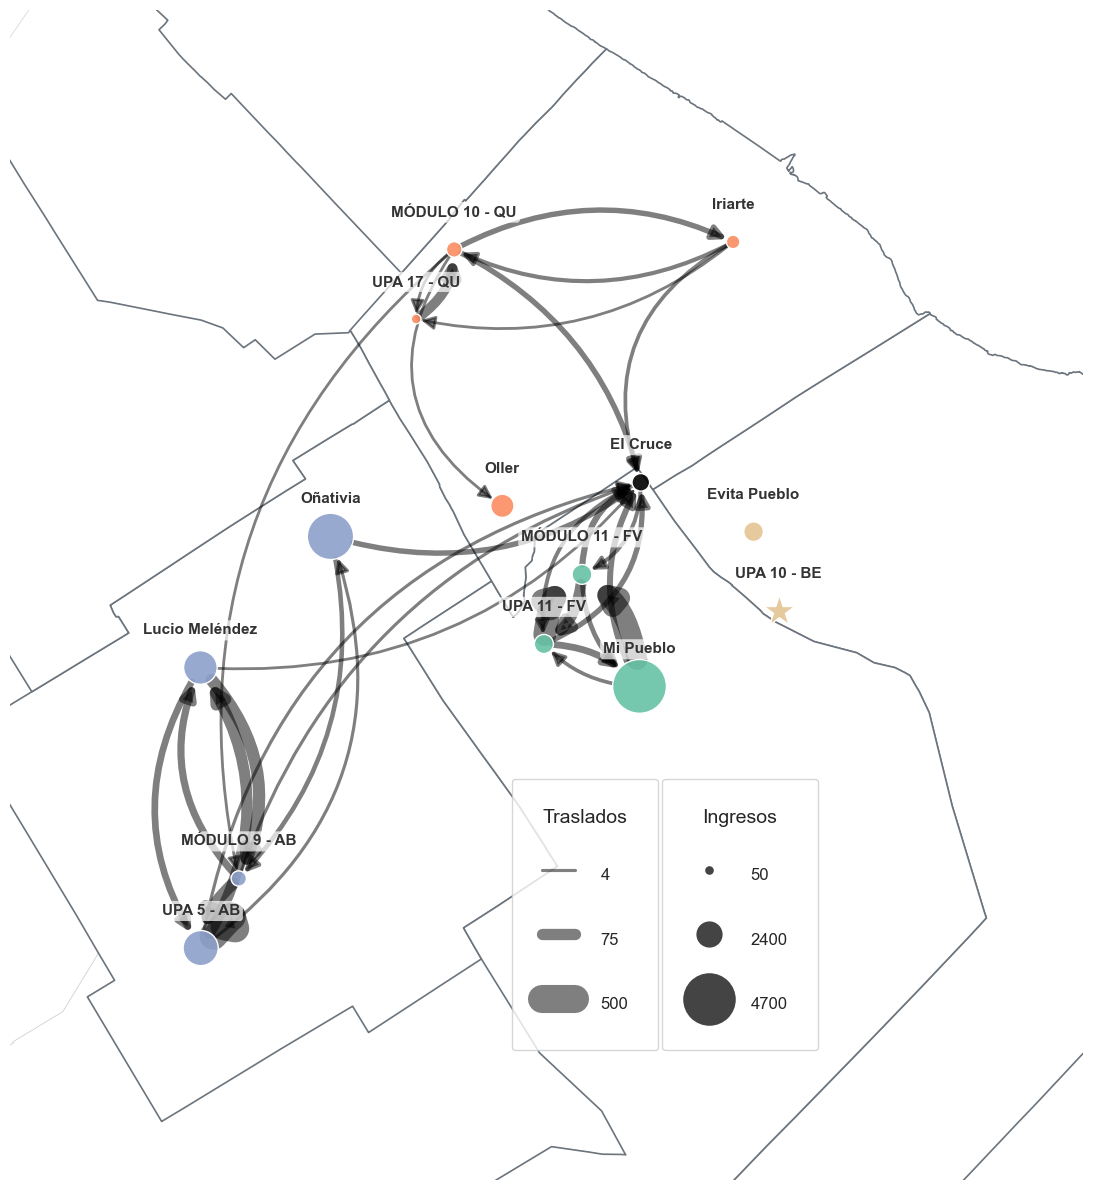

In [19]:
# GRÁFICO 2: MAPA GEOPANDAS
# ==========================================
fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('white')

min_i_g = ingresos_globales_ser.min() if not ingresos_globales_ser.empty else 0

cfg_geo = {
    'min_grosor': 0.5, 'max_grosor': 20.0, 'min_tamano': 50, 'max_tamano': 1500,
    'escala_nodo': 'cuadratica', 'color_por_origen': False, 'alpha_arista': 0.5, 'aristas_negras': True,
    'arrow_size': 20, 'node_size_edge': 600, 'lbl_offset': 0.008, 'lbl_size': 11,
    'lbl_weight': 'bold', 'lbl_color': '#333333', 'lbl_bbox': True, 'zorder_nodos': 5, 
    'zorder_aristas': 6, 'lw_nodos': 1.0, 'forzar_i_min_50': True, 'min_ingresos_real': min_i_g,
    'leg_title_sz': 14, 'leg_lbl_sz': 12, 'leg_dynamic_spc': True, 'lbl_bbox_alpha': 0.7,
}

deptos = gpd.read_file("../data/shapefiles/departamento/departamentoPolygon.shp")
pba = deptos[deptos["in1"].astype(str).str.startswith("06")].to_crs(epsg=4326)
sudeste = pba[pba["nam"].astype(str).str.upper().isin(["QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA", "AVELLANEDA", "MORON", "ITUZAINGO"])]

pba.plot(ax=ax, color="#FFFFFF", edgecolor="#ced4da", linewidth=0.5, zorder=0)
sudeste.plot(ax=ax, color="#FFFFFF", edgecolor="#6c757d", linewidth=1.2, zorder=1)

# Usamos los pre-cálculos globales, mucho más rápido y limpio
tras_dib_geo = traslados_globales_grp[traslados_globales_grp > 2]
max_t_g_geo = tras_dib_geo.max() if not tras_dib_geo.empty else 1

G_geo = nx.DiGraph()
for _, row in df_coordenadas.iterrows():
    cant = ingresos_globales_ser.get(row['hospital'], 0)
    sz = aplicar_escala_visual(cant, max_ing_glob, cfg_geo['min_tamano'], cfg_geo['max_tamano'], 'cuadratica', min_valor=cfg_geo['min_ingresos_real'])
    G_geo.add_node(row['hospital'], pos=(row['lon'], row['lat']), color=row.get('color_rgb', 'grey'), size=sz, shape=MAPA_FORMAS.get(row['shape'], 'o'), alpha=0.9 if cant > 0 else 0.4)

for (u, v), peso in tras_dib_geo.items():
    G_geo.add_edge(u, v, weight=peso)

dibujar_grafo_nx(ax, G_geo, nx.get_node_attributes(G_geo, 'pos'), max_t_g_geo, max_ing_glob, cfg_geo)

ax.set_xlim(df_coordenadas['lon'].min() - 0.05, df_coordenadas['lon'].max() + 0.08)
ax.set_ylim(df_coordenadas['lat'].min() - 0.05, df_coordenadas['lat'].max() + 0.05)

generar_leyendas(ax, max_t_g_geo, min_i_g, max_ing_glob, max_t_g_geo, max_ing_glob, cfg_geo, [(0.46, 0.35), None, (0.60, 0.35)])

plt.tight_layout()
guardar_pdf('gen_mapa_redsudeste_global', subcarpeta='general')
plt.show()

,Primera Ola,Intermedia,Segunda Ola,Post-vacunación
Días totales,153,120,153,518
Admisiones (Prom. diario),5944 (38.8),2839 (23.7),6193 (40.5),11347 (21.9)
Pacientes admitidos,5363,2558,5474,10601
Traslados totales (% admisiones),482 (8.1%),218 (7.7%),526 (8.5%),509 (4.5%)
Pacientes trasladados,451,193,501,452
Promedio diario de traslados,3.2,1.8,3.4,1.0
Traslados en ambulancia (% total),272 (56.4%),120 (55.0%),210 (39.9%),103 (20.2%)
Traslados UPA-Módulos,275,153,361,463
Rutas UPA-Módulos,17,17,16,15
Rutas totales | Ambulancia,38 | 32,28 | 23,31 | 25,21 | 15


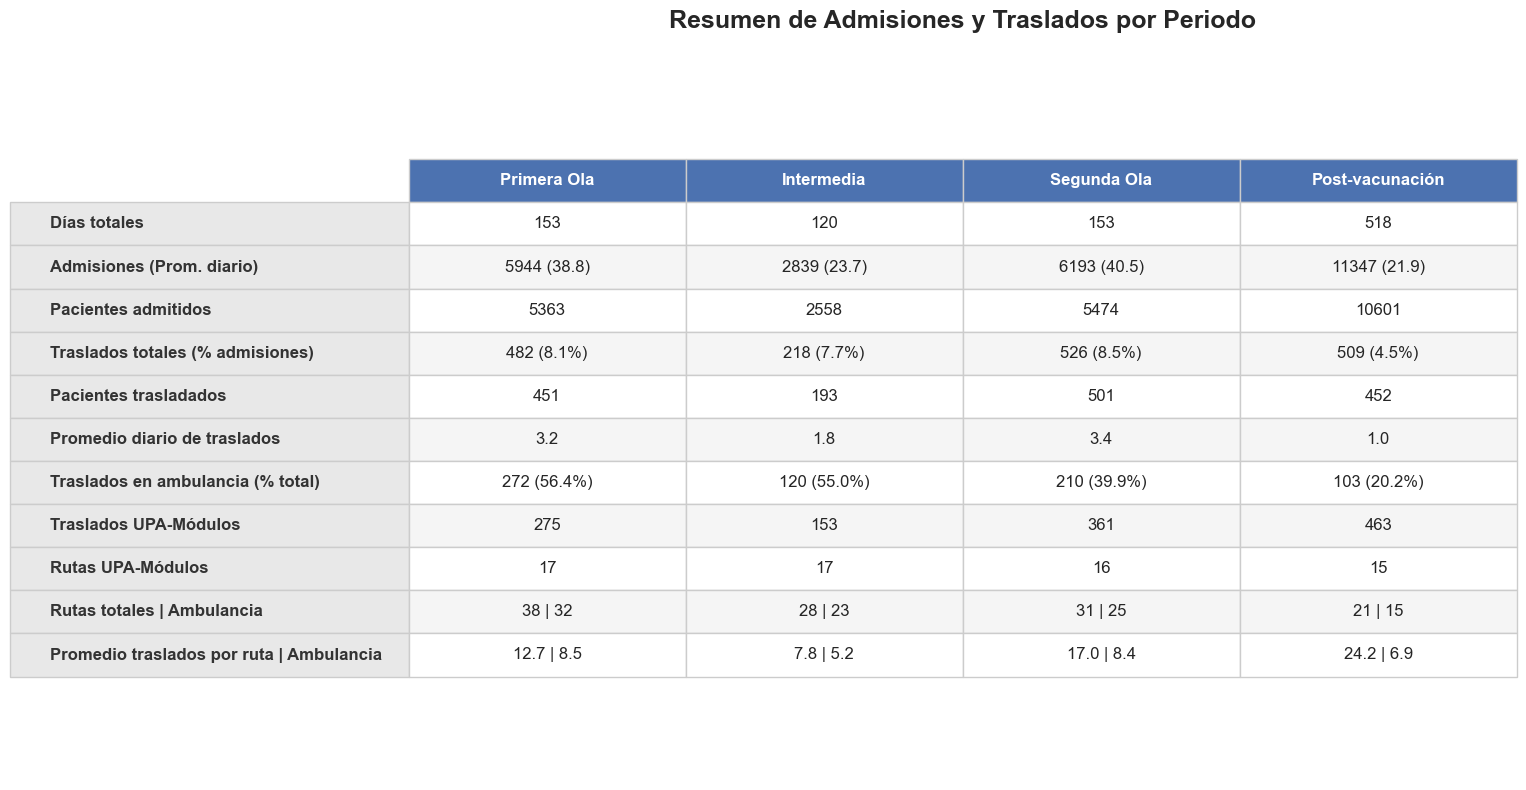

In [20]:
# 7. GENERACIÓN DE TABLA RESUMEN (MÉTRICAS)
# ==========================================

df_aristas_traslados['es_ambulancia'] = df_aristas_traslados.apply(requiere_ambulancia, axis=1)


# EJECUCIÓN SECCIÓN 7
tabla_resumen = generar_tabla_resumen(df_base, df_aristas_traslados, PERIODOS, hospitales_conocidos)
display(tabla_resumen)
exportar_tabla_estetica(tabla_resumen)


- PICO DE ESTRES SEGUNDA OLA: admisiones y traslados: en segunda ola aumentan mucho , y tmb el porcentaje de traslados respecto a ingresos
- BAJA DE AMBULANCIAS: o se optimizaron otros medios, o la red UPA-MODULOS empezo a absorber pacientes que antes requerian ser trasladados
- CONSOLIDACION DE RUTAS: bajaron mucho las rutas pero aumentaron los traslados por ruta , es decir que el sistema aprendió y se institucionalizaron ciertos caminos. Ya no se mandaban pacientes "a donde hubiera lugar", sino que se establecieron corredores sanitarios claros.

TypeError: DataFrame.__init__() got an unexpected keyword argument 'square'

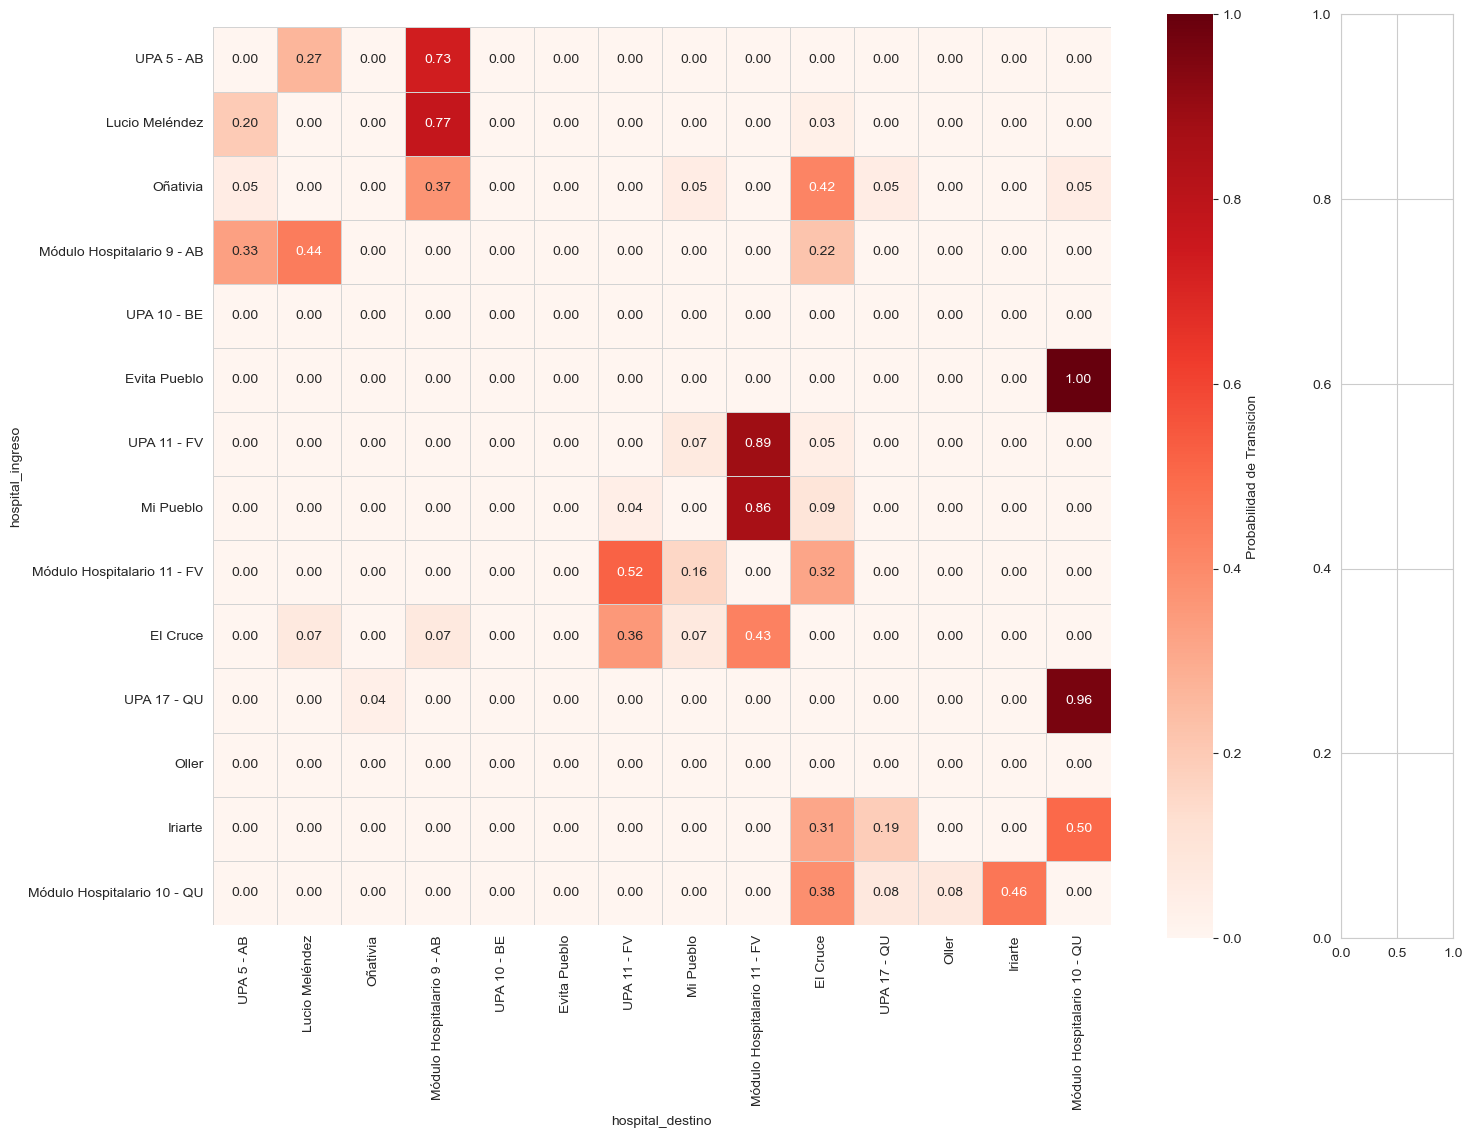

In [21]:
# 8. GENERACIÓN DE MATRICES
# ==============================================================================

# EJECUCIÓN SECCIÓN 8
ini_estudio, fin_estudio = PERIODOS[0][1], PERIODOS[0][2]
generar_matrices_traslados(df_aristas_traslados, df_base, hospitales, ini_estudio, fin_estudio, 'probabilidad')
generar_matrices_traslados(df_aristas_traslados, df_base, hospitales, ini_estudio, fin_estudio, 'cantidad')

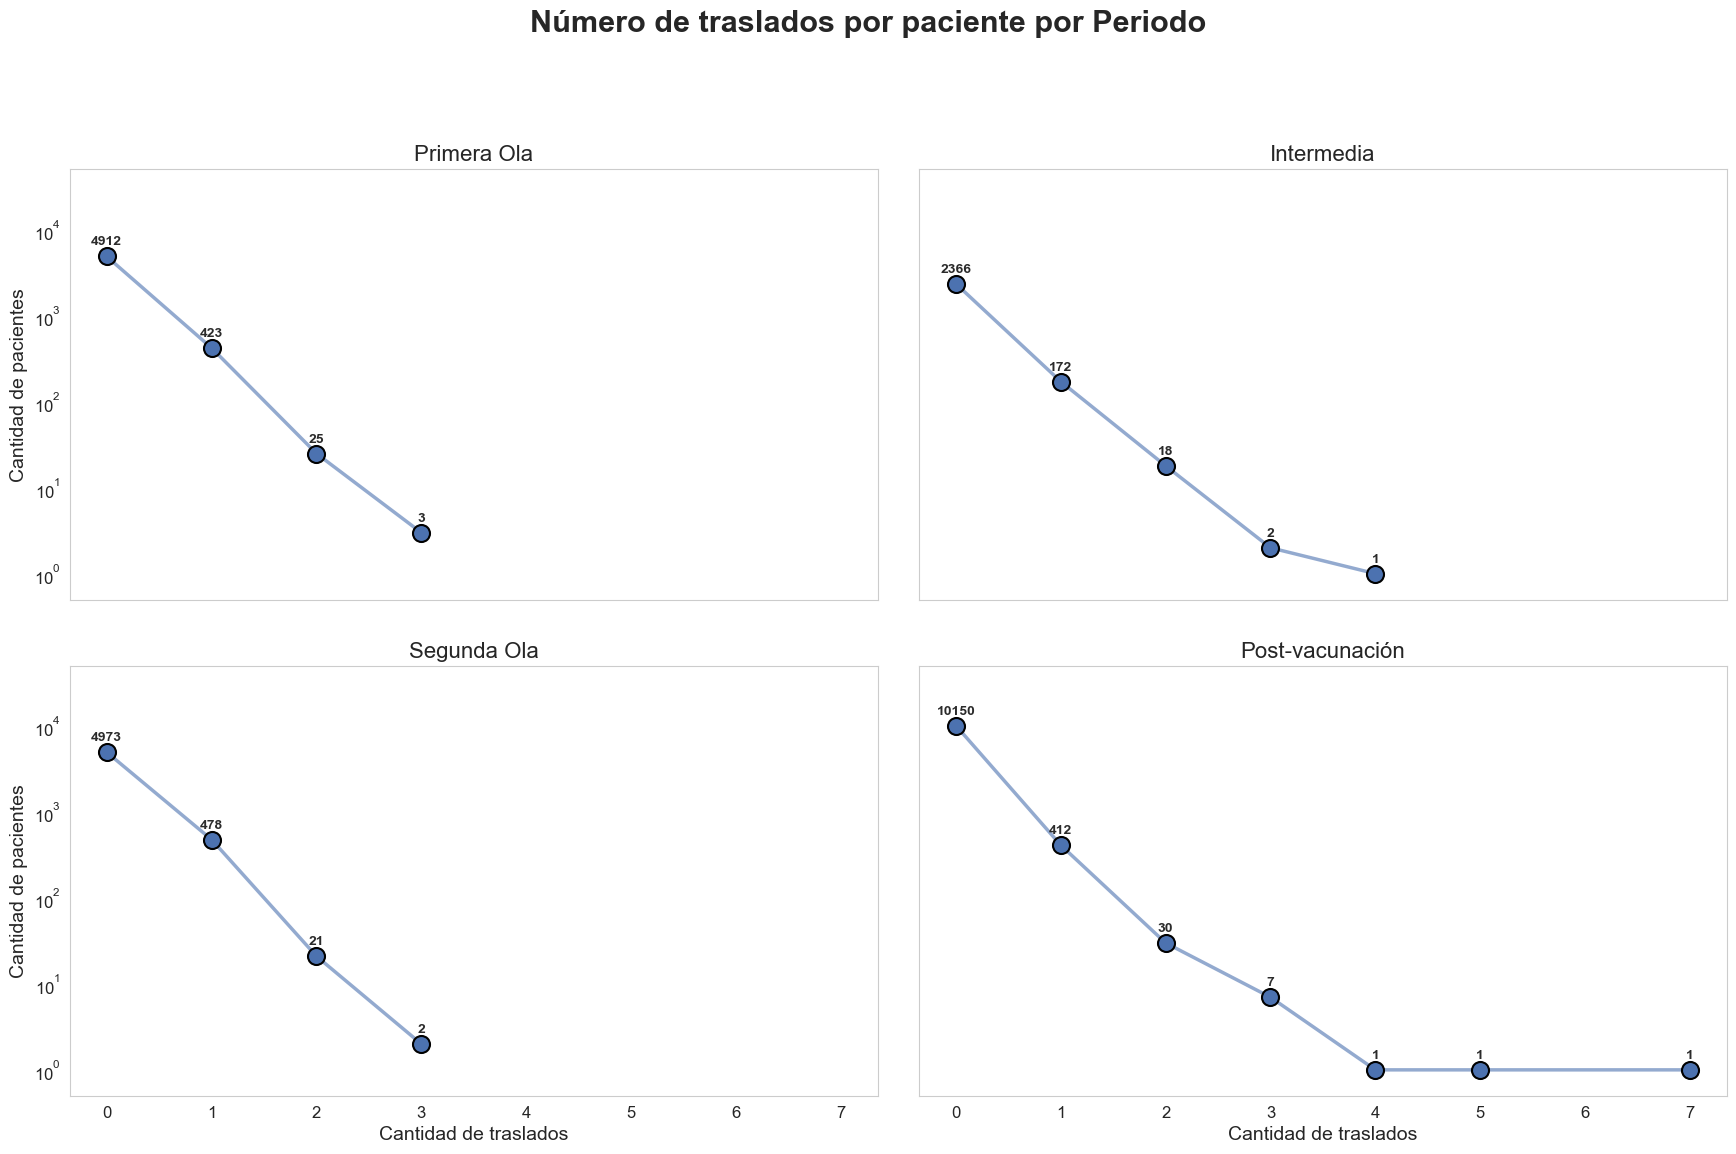

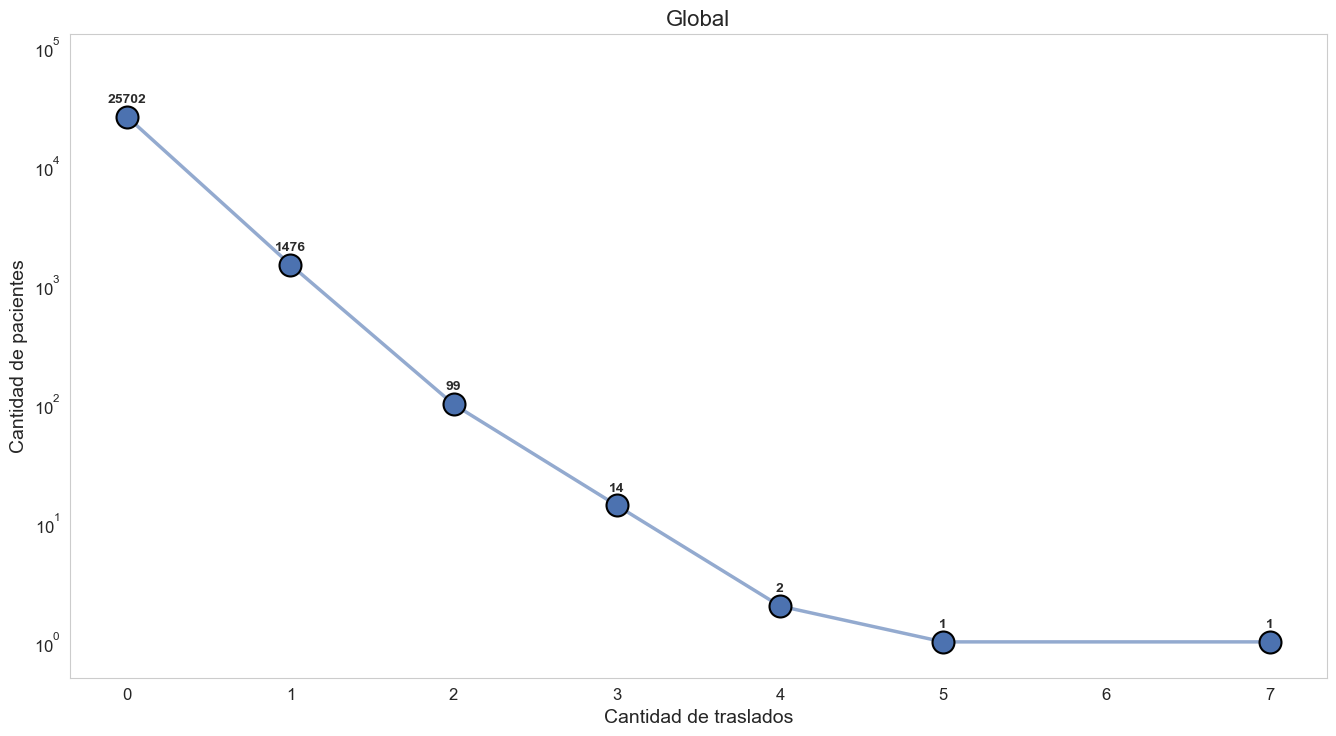

--------------------------------------------------
PROMEDIO DE TRASLADOS POR PACIENTE (INCLUYE 0s):
Primera Ola: 0.0899
Intermedia: 0.0852
Segunda Ola: 0.0961
Post-vacunación: 0.0480
Global: 0.0636
--------------------------------------------------


C:\Users\micag\AppData\Local\Temp\ipykernel_11796\3908860546.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_trasladados = tiempo_trayectorias_todas[mask_trasladados]
c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:355: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96 if not es_global else 1], pad=3.0)


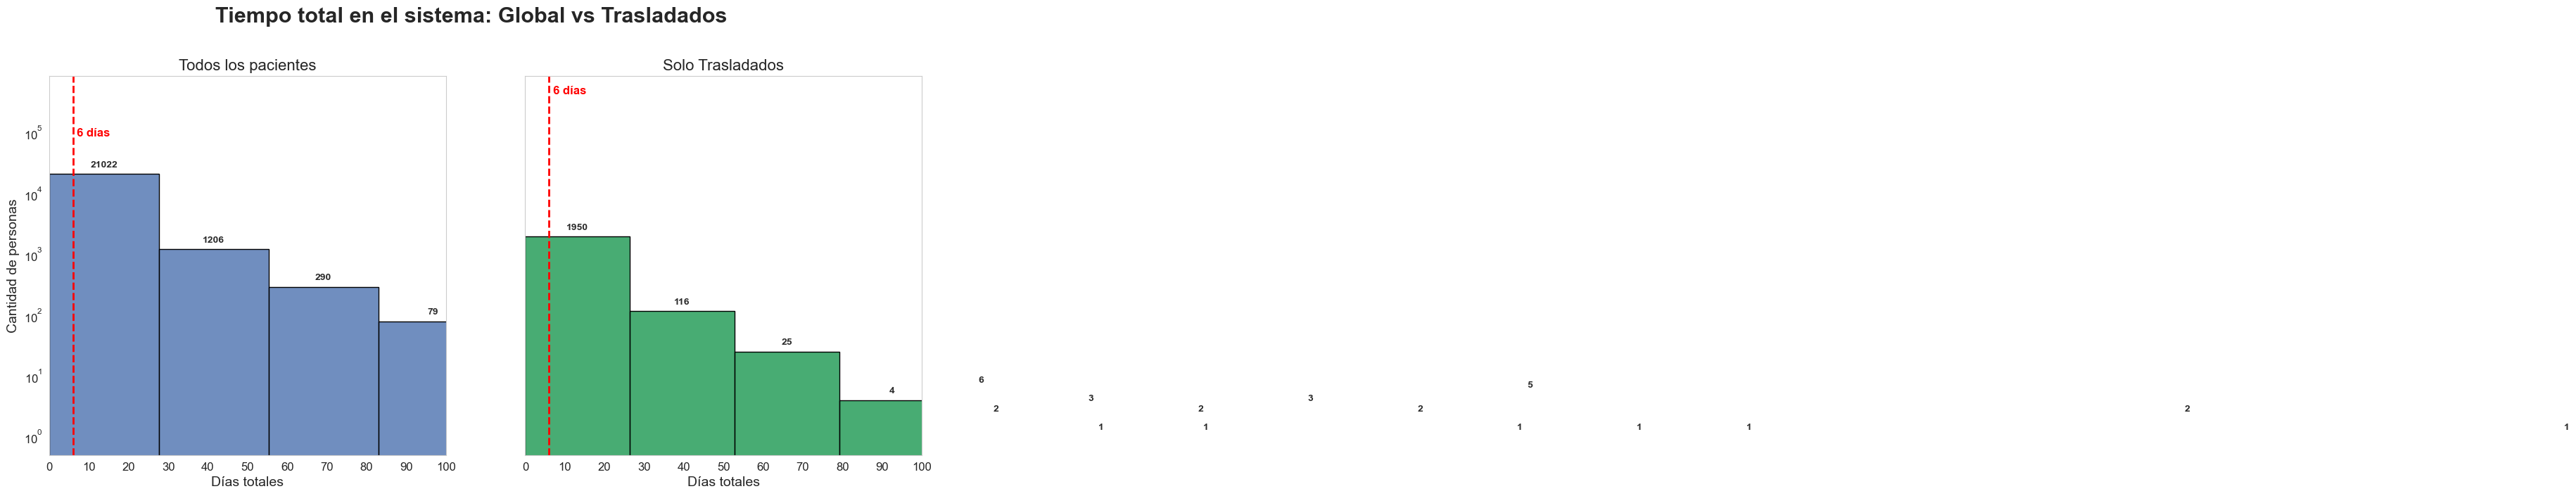

c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:355: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96 if not es_global else 1], pad=3.0)


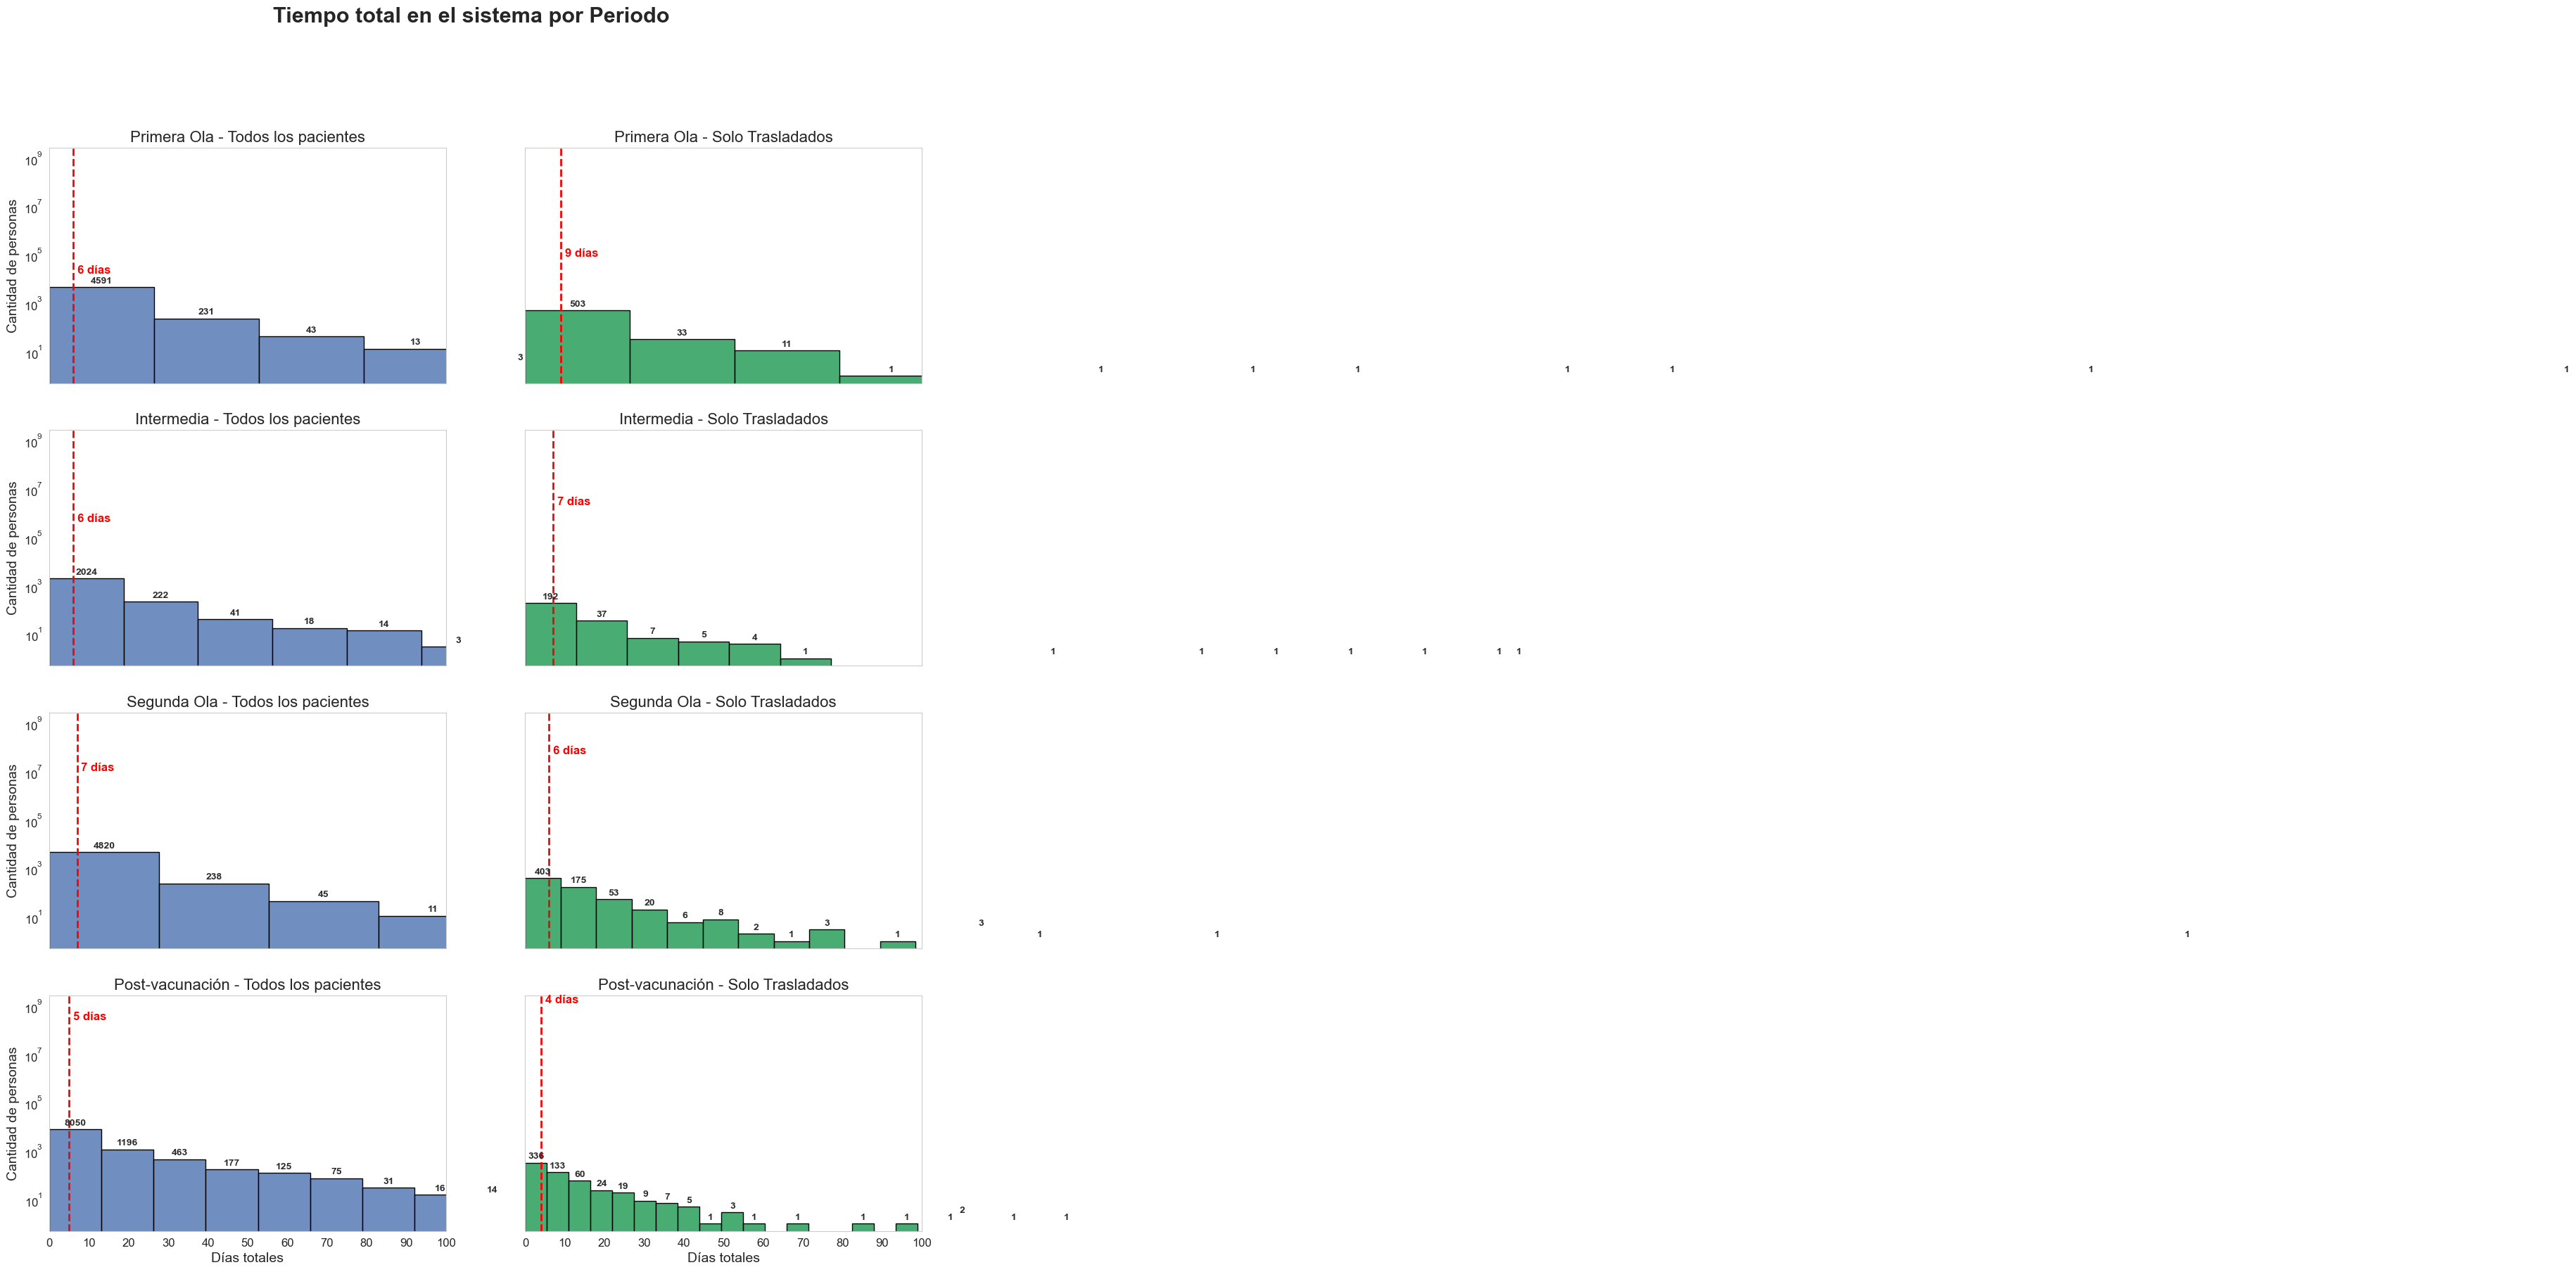

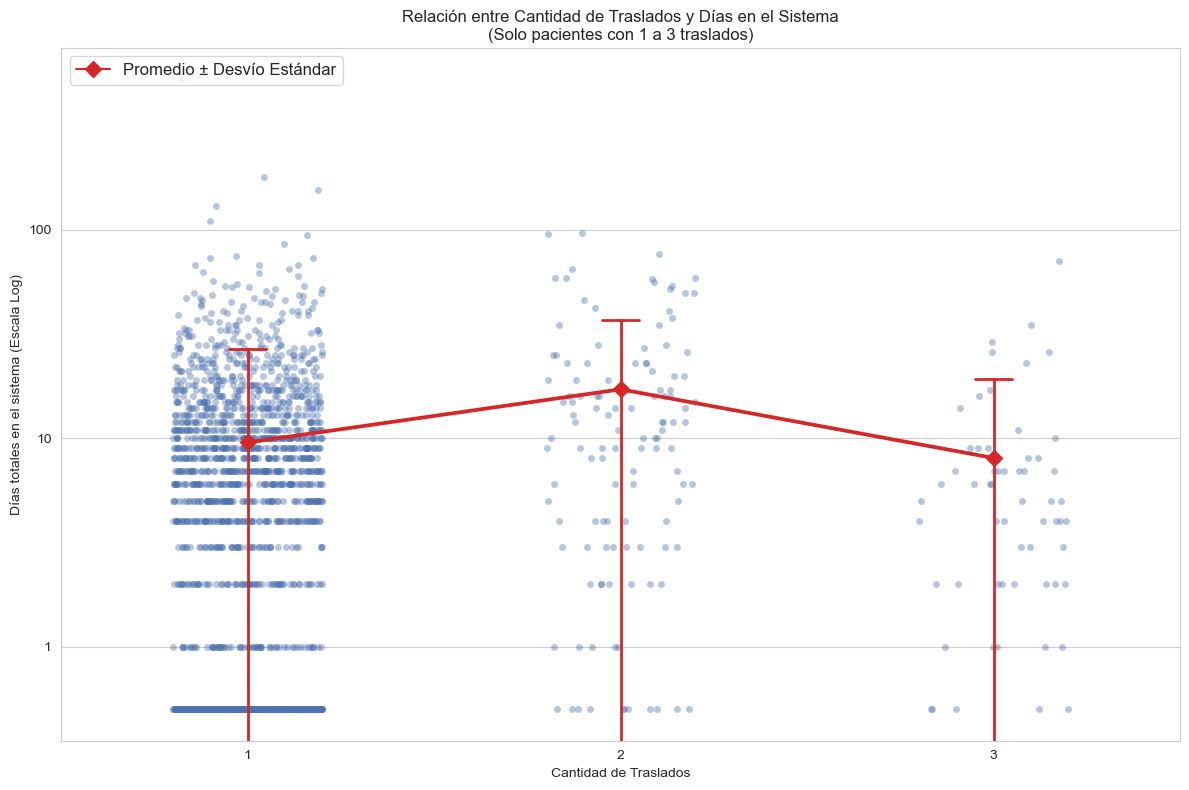

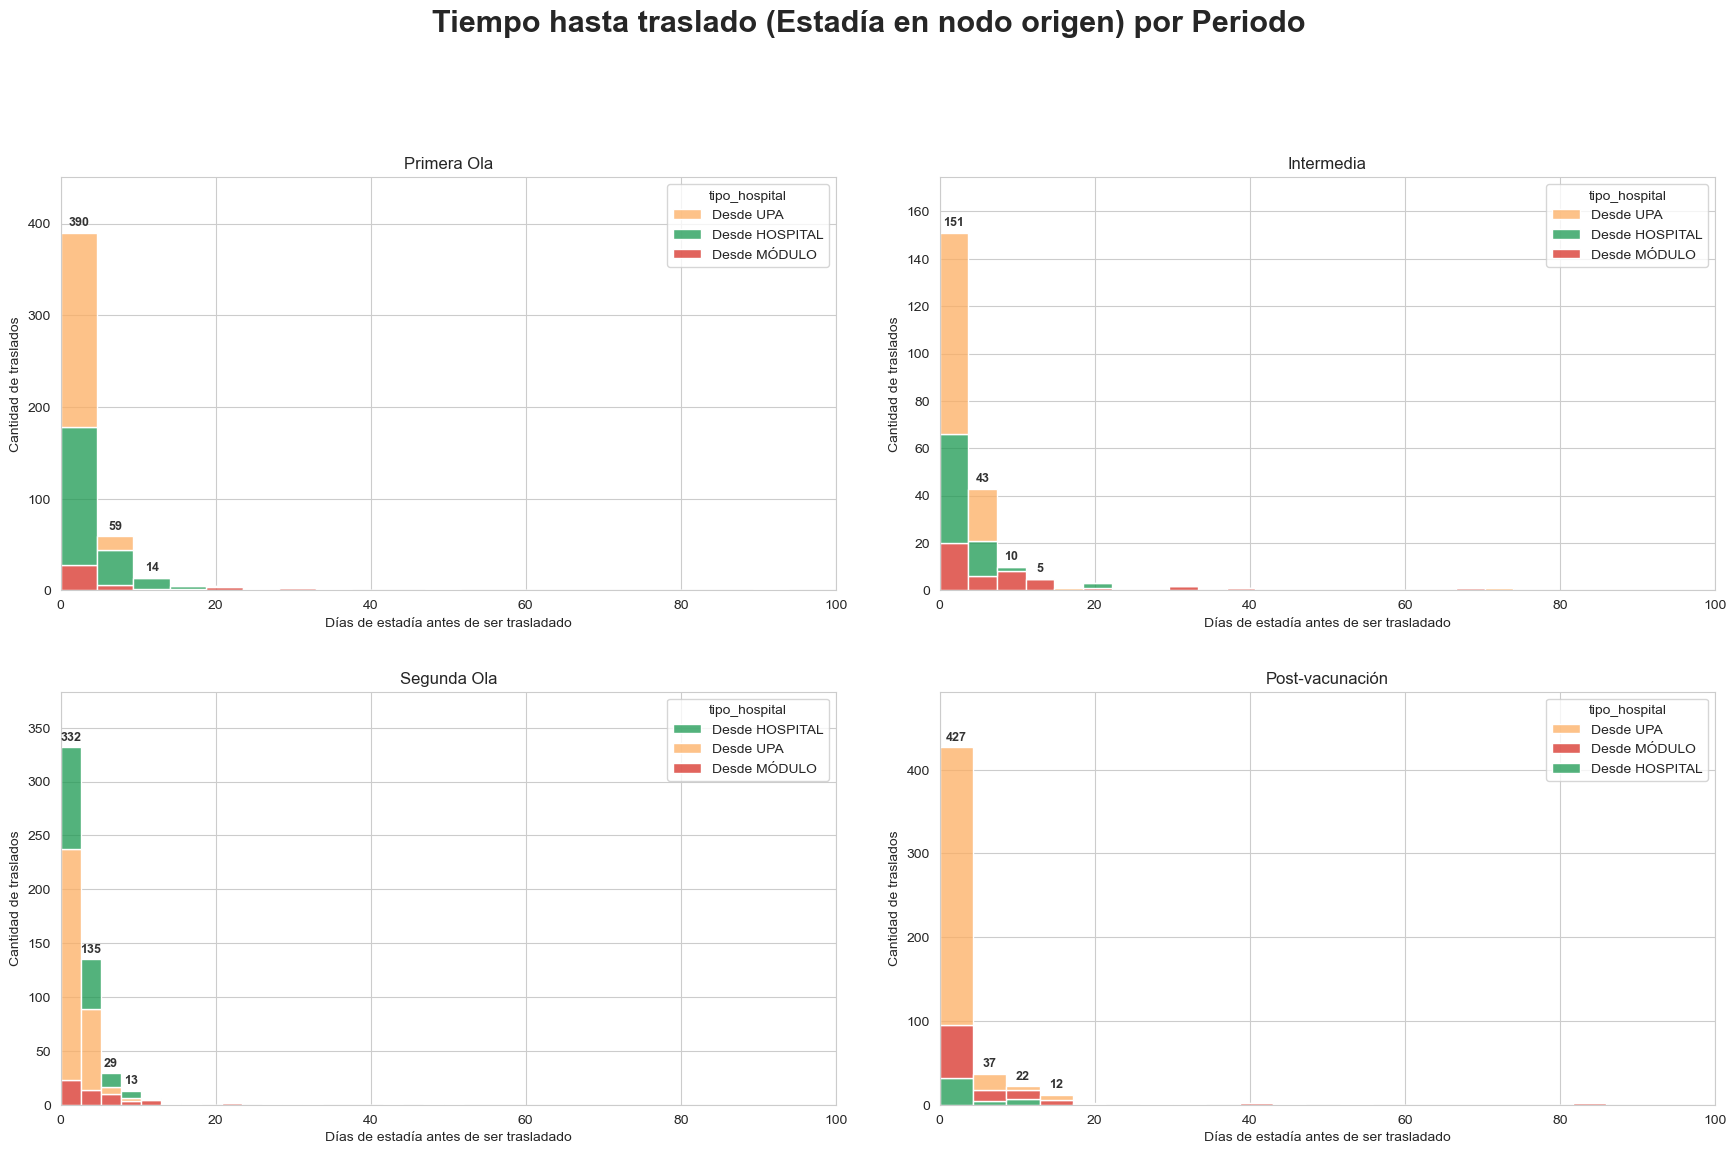

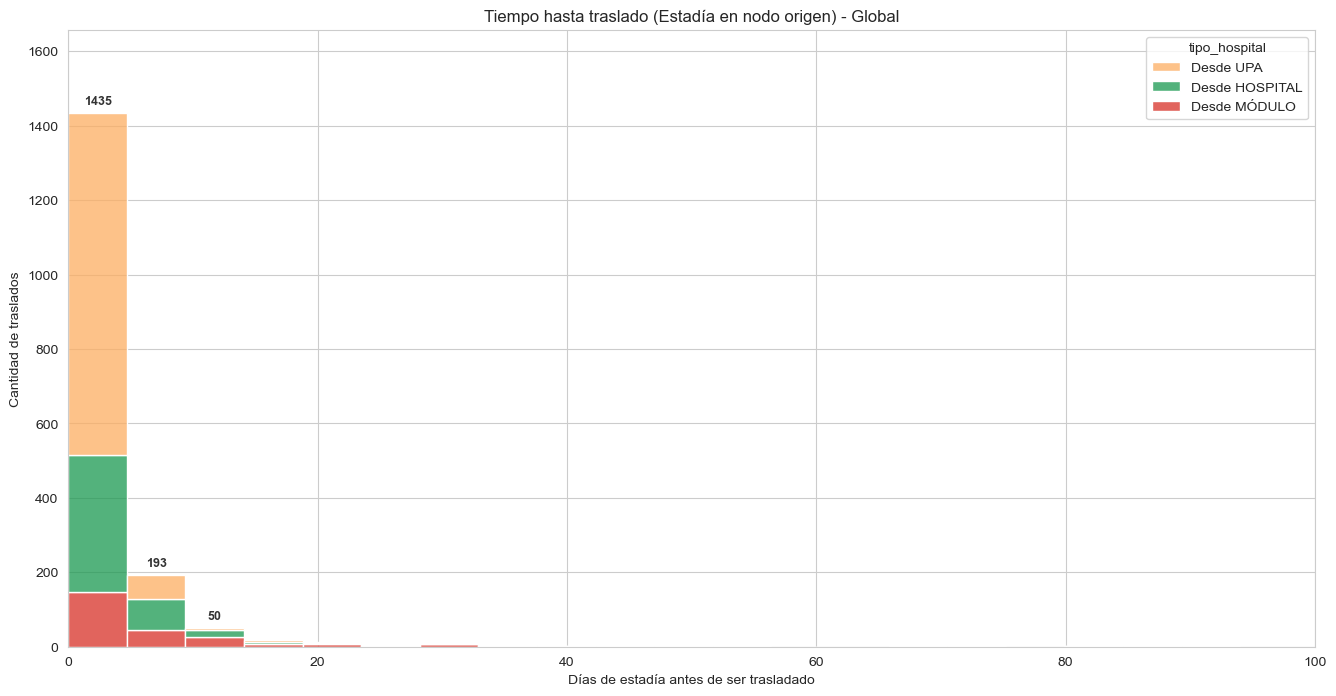

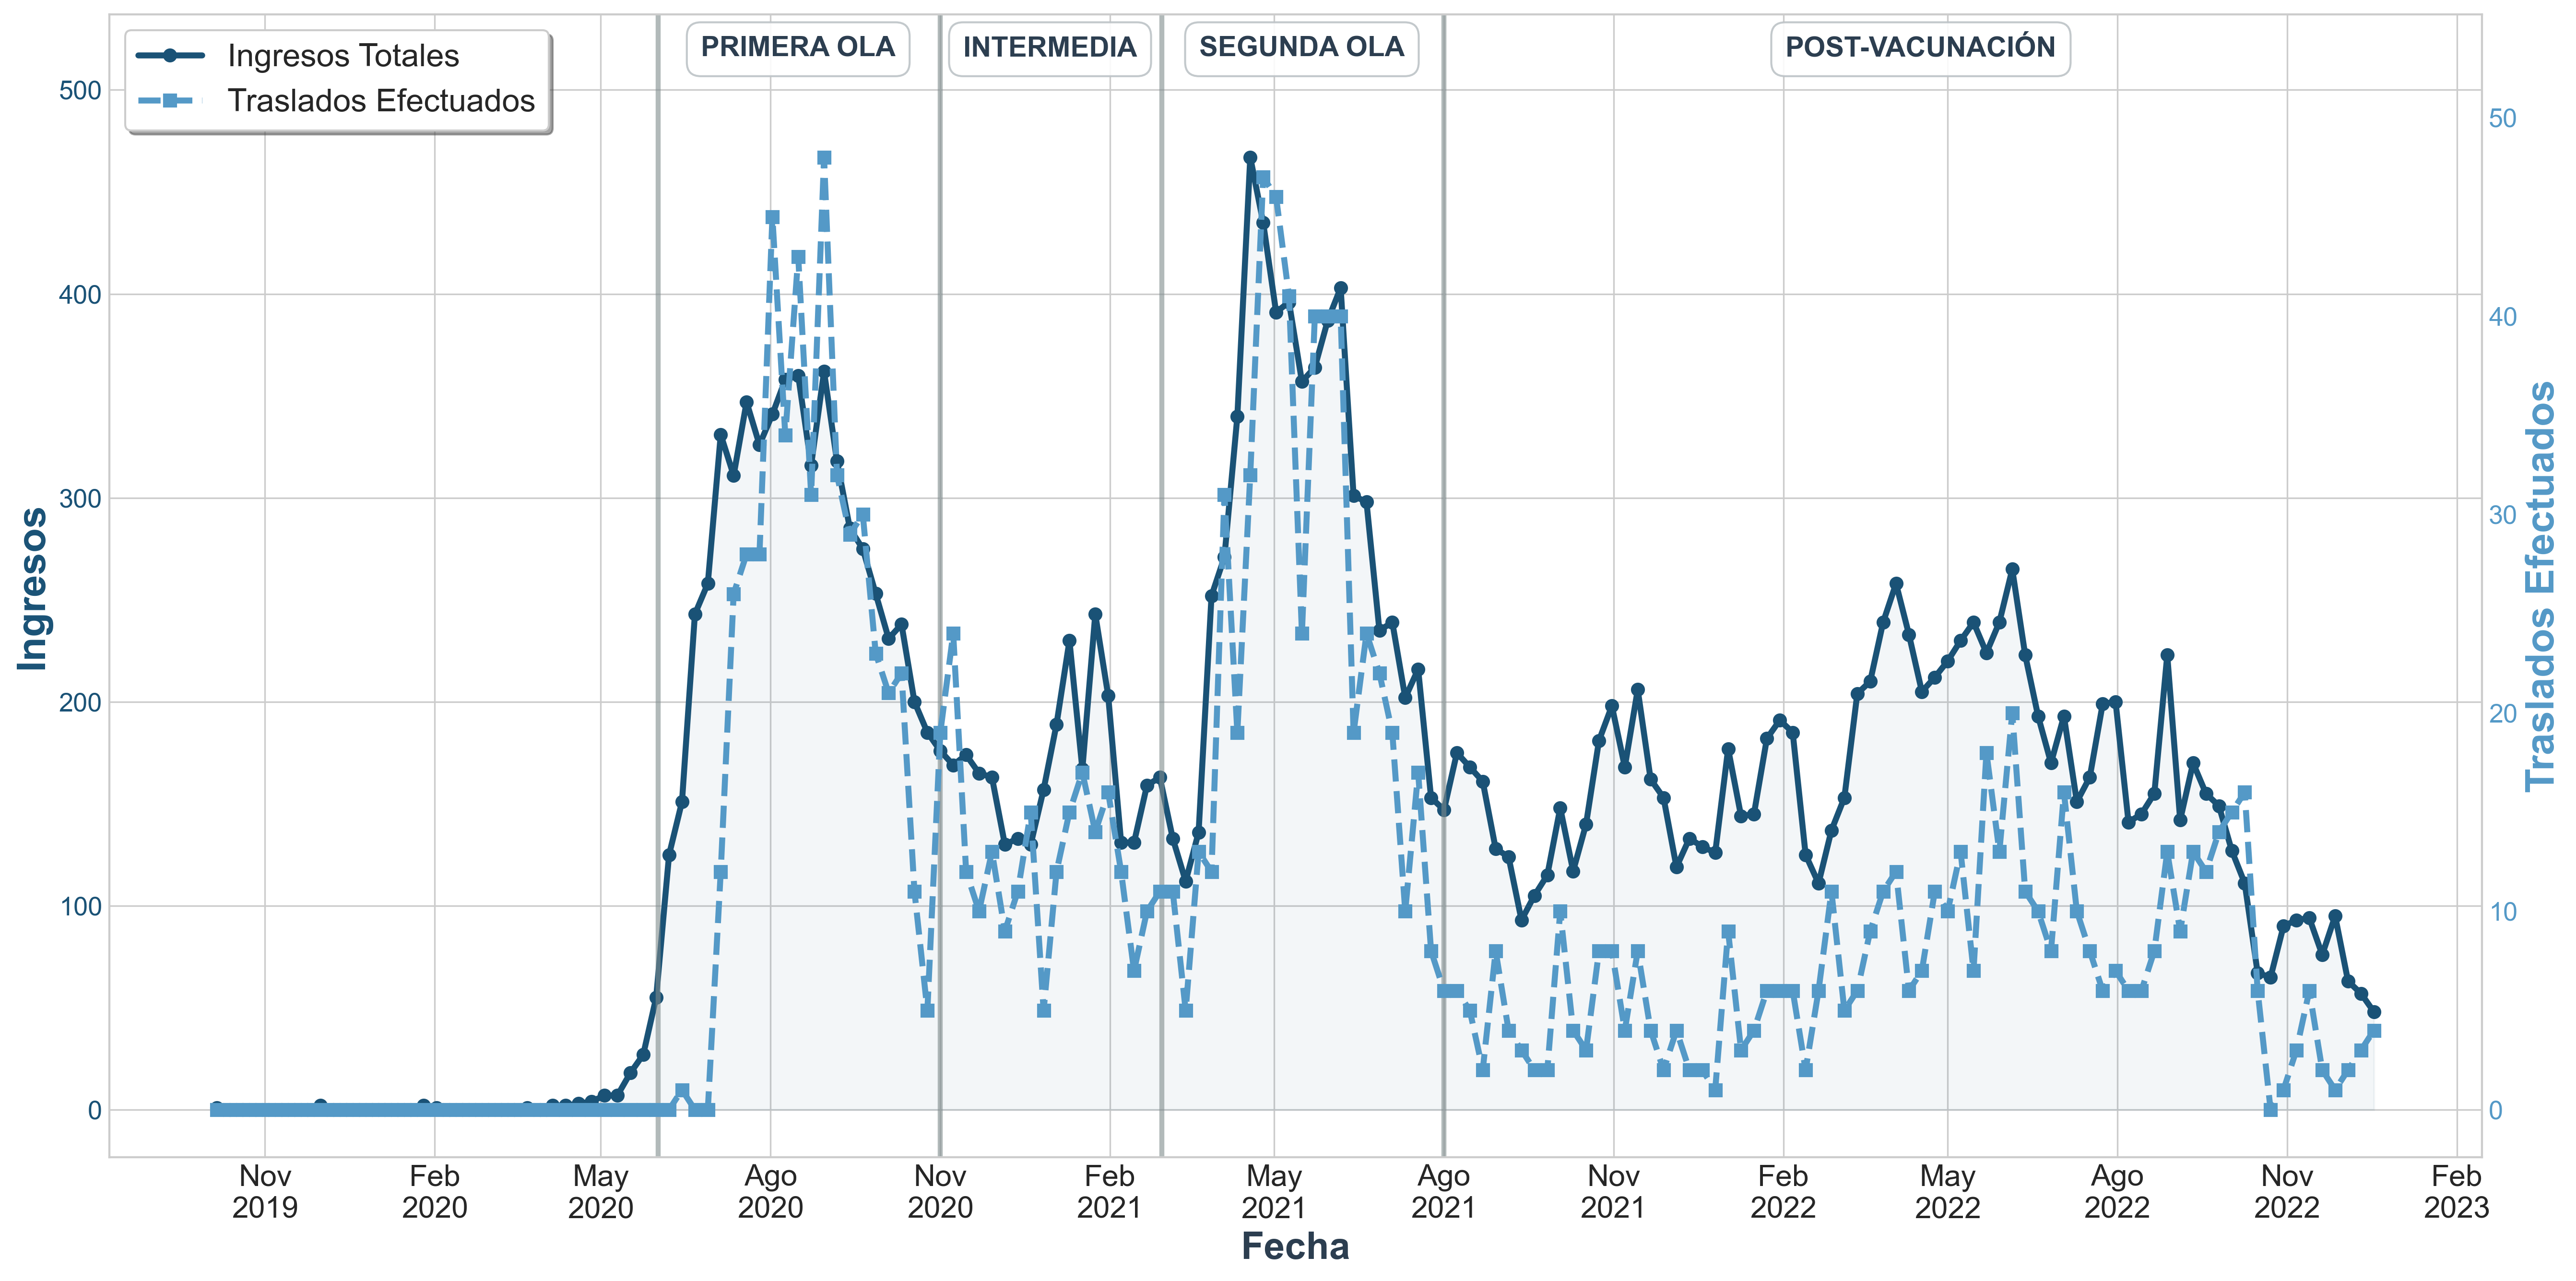

In [8]:
# # 9. ANÁLISIS ESTADÍSTICO Y TEMPORAL (DRY)
# # ==========================================
mask_validos_stats = (
    (df_aristas_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & 
    (df_aristas_traslados['hospital_destino'].isin(hospitales_conocidos)) & 
    (df_aristas_traslados['hospital_ingreso'] != df_aristas_traslados['hospital_destino'])
)
df_aristas_traslados_stats = df_aristas_traslados[mask_validos_stats].copy()

# --- 9.1 Gráfico de Puntos Conectados (Ex Lollipop) ---
promedios_traslados = {}

graficar_traslados_paciente(df_aristas_traslados_stats, df_base, es_global=False, promedios_traslados=promedios_traslados)
graficar_traslados_paciente(df_aristas_traslados_stats, df_base, es_global=True, promedios_traslados=promedios_traslados)

print("-" * 50)
print("PROMEDIO DE TRASLADOS POR PACIENTE (INCLUYE 0s):")
for periodo, prom in promedios_traslados.items():
    print(f"{periodo}: {prom:.4f}")
print("-" * 50)


# --- 9.2 Tiempo en el Sistema Histograms (SÚPER OPTIMIZADO) ---
# Usamos df_pacientes_trayectorias que YA TIENE todo calculado
# Lo formateamos igual que tu código original para que no se rompa la función de ploteo
tiempo_trayectorias_todas = df_pacientes_trayectorias.set_index('paciente_id').rename(columns={
    'fecha_ingreso_red': 'ingreso',
    'fecha_egreso_red': 'egreso',
    'dias_estadia_total': 'dias_en_sistema'
})[['ingreso', 'egreso', 'dias_en_sistema']].copy()

tiempo_trayectorias_todas = tiempo_trayectorias_todas[tiempo_trayectorias_todas['dias_en_sistema'] >= 0]

# En vez de un cruce (isin), simplemente filtramos los que tienen más de 0 traslados
mask_trasladados = df_pacientes_trayectorias.set_index('paciente_id')['cantidad_traslados'] > 0
df_trasladados = tiempo_trayectorias_todas[mask_trasladados]

limite_p99 = tiempo_trayectorias_todas['dias_en_sistema'].quantile(0.99)
max_plot = int(limite_p99) if not pd.isna(limite_p99) else int(tiempo_trayectorias_todas['dias_en_sistema'].max())
bins_5dias = np.arange(0, max_plot + 5, 5)

graficar_tiempo_sistema(tiempo_trayectorias_todas, df_trasladados, es_global=True)
graficar_tiempo_sistema(tiempo_trayectorias_todas, df_trasladados, es_global=False)


# --- 9.3 Scatter de Traslados vs Tiempo (< 4) (SÚPER OPTIMIZADO) ---
# Chau pd.merge! Ya tenemos 'cantidad_traslados' y 'dias_estadia_total' juntos.
# Filtramos entre 1 y 3 traslados (tu inner join original excluía los de 0 traslados)
df_plot = df_pacientes_trayectorias[
    (df_pacientes_trayectorias['cantidad_traslados'] > 0) & 
    (df_pacientes_trayectorias['cantidad_traslados'] < 4)
].copy()

df_plot['dias_plot'] = df_plot['dias_estadia_total'].replace(0, 0.5)

fig3, ax3 = plt.subplots(figsize=(12, 8))
fig3.patch.set_facecolor('white')
sns.stripplot(data=df_plot, x='cantidad_traslados', y='dias_plot', color='#4c72b0', alpha=0.4, jitter=0.2, size=5, ax=ax3, zorder=1)
sns.pointplot(data=df_plot, x='cantidad_traslados', y='dias_plot', estimator=np.mean, errorbar='sd', color='#d62728', markers='D', capsize=0.1, err_kws={'linewidth': 2}, ax=ax3, zorder=3)

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:g}'.format(y)))
ax3.set(title="Relación entre Cantidad de Traslados y Días en el Sistema\n(Solo pacientes con 1 a 3 traslados)", xlabel="Cantidad de Traslados", ylabel="Días totales en el sistema (Escala Log)")
ax3.legend(handles=[mlines.Line2D([], [], color='#d62728', marker='D', markersize=8, label='Promedio ± Desvío Estándar')], loc='upper left', frameon=True, fontsize=12)
plt.tight_layout()
plt.show()


# --- 9.4 Tiempo hasta Traslado (Barras Apiladas) ---
df_movimientos = df_aristas_traslados_stats.copy()
df_movimientos['dias_antes_traslado'] = (df_movimientos['fecha_egreso'] - df_movimientos['fecha_ingreso']).dt.days
df_movimientos = df_movimientos[df_movimientos['dias_antes_traslado'] >= 0]
df_movimientos['tipo_hospital'] = df_movimientos['hospital_ingreso'].apply(clasificar_hospital)

limite_p99_nodo = df_movimientos['dias_antes_traslado'].quantile(0.99) if not df_movimientos.empty else 30
max_plot_nodo = int(limite_p99_nodo) if not pd.isna(limite_p99_nodo) else 30
bins_mov_5 = np.arange(0, max_plot_nodo + 5, 5)

graficar_tiempo_traslado(df_movimientos, es_global=False)
graficar_tiempo_traslado(df_movimientos, es_global=True)


# --- 9.5 Evolución Temporal (Escalas Duales + Meses en Español + Paleta Azul) ---
# Aplicamos un estilo base limpio
plt.style.use('seaborn-v0_8-whitegrid')
fig4, ax4 = plt.subplots(figsize=(18, 9), dpi=300)
fig4.patch.set_facecolor('#ffffff')

# Resampleo semanal
df_ts = pd.concat([
    df_base.set_index('fecha_ingreso').resample('W').size().rename('Ingresos Totales'),
    df_aristas_traslados_stats.set_index('fecha_egreso').resample('W').size().rename('Traslados')
], axis=1).fillna(0)

# Volvemos a la Paleta Azulada
color_ingresos = '#1a5276'  # Azul oscuro / SteelBlue
color_traslados = '#5499c7'  # Azul claro brillante

# --- EJE IZQUIERDO: INGRESOS ---
lns1 = ax4.plot(df_ts.index, df_ts['Ingresos Totales'], label='Ingresos Totales', 
                color=color_ingresos, linewidth=3, marker='o', markersize=6)
ax4.fill_between(df_ts.index, df_ts['Ingresos Totales'], color=color_ingresos, alpha=0.05)
ax4.set_ylabel("Ingresos", fontsize=20, fontweight='bold', color=color_ingresos)
ax4.tick_params(axis='y', labelcolor=color_ingresos, labelsize=13)

# --- EJE DERECHO: TRASLADOS (twinx) ---
ax4_twin = ax4.twinx()
lns2 = ax4_twin.plot(df_ts.index, df_ts['Traslados'], label='Traslados Efectuados', 
                     color=color_traslados, linewidth=3, marker='s', markersize=6, linestyle='--')
ax4_twin.set_ylabel("Traslados Efectuados", fontsize=20, fontweight='bold', color=color_traslados)
ax4_twin.tick_params(axis='y', labelcolor=color_traslados, labelsize=13)
ax4_twin.grid(False) # Evitamos que las grillas se superpongan

# Ajuste de límites para que las etiquetas de período no choquen
ax4.set_ylim(top=df_ts['Ingresos Totales'].max() * 1.15)
ax4_twin.set_ylim(top=df_ts['Traslados'].max() * 1.15)

# Períodos (Solo líneas separadoras y texto, sin fondo de color)
for i, (titulo, inicio, fin) in enumerate(PERIODOS):
    f_ini, f_fin = pd.to_datetime(inicio), pd.to_datetime(fin)
    
    # Línea divisoria gruesa
    ax4.axvline(f_ini, color='#7f8c8d', linestyle='-', linewidth=2.5, alpha=0.6)
    
    # Etiqueta del período más alta y grande
    ax4.text(f_ini + (f_fin - f_ini)/2, ax4.get_ylim()[1]*0.98, titulo.upper(), 
             ha='center', va='top', fontsize=14, fontweight='bold', color='#2c3e50',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

# --- TRUCO PARA MESES EN ESPAÑOL ---
meses_es = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 
            7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}

def formato_fecha_es(x, pos):
    fecha = mdates.num2date(x)
    return f"{meses_es[fecha.month]}\n{fecha.year}"

ax4.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_es))
# -----------------------------------

# Configuración de Eje X y Títulos
ax4.set_xlabel("Fecha", fontsize=19, fontweight='bold', color='#2c3e50')
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax4.tick_params(axis='x', labelsize=15)

# plt.title("Evolución Temporal: Ingresos vs Traslados", 
#           fontsize=20, fontweight='bold', pad=30, color='#2c3e50')

# Combinar leyendas de ambos ejes en una sola
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax4.legend(lns, labs, loc='upper left', fontsize=16, frameon=True, shadow=True)

plt.tight_layout()

# --- Guardado usando tu función personalizada ---
guardar_pdf(nombre_archivo="09_evolucion_temporal_ingresos_traslados", subcarpeta="evolucion")

# Mostramos el gráfico
plt.show()

In [9]:
# CONSULTAS, FILTROS, RESULTADOS Y EXPORTACIÓN
# ==========================================

# ---------------------------------------------------------
# 1. PARÁMETROS PARA LOS CÁLCULOS
# ---------------------------------------------------------
# Definimos un periodo, un hospital y un ID de interés para hacer las pruebas
fecha_inicio_filtro = '2020-06-01'
fecha_fin_filtro = '2022-12-31'
hospital_interes = 'Evita Pueblo'
id_buscado = 'WN04' # Reemplazar por el ID real

# ---------------------------------------------------------
# 2. BÚSQUEDAS ESPECÍFICAS (OPCIONALES PARA TESTING)
# ---------------------------------------------------------
# Buscar un paciente en particular en la base
historia_paciente = df_base[df_base['paciente_id'] == id_buscado]

# Detectar traslados lentos (> 2 días de demora logística)
traslados_lentos = df_aristas_traslados[df_aristas_traslados['dias_traslado'] > 2]

# ---------------------------------------------------------
# 3. CONTADORES (INGRESOS Y TRASLADOS EN EL PERIODO)
# ---------------------------------------------------------
# A. Contar Ingresos (Totales vs Un Hospital)
mask_periodo_ingresos = df_base['fecha_ingreso'].between(fecha_inicio_filtro, fecha_fin_filtro)
ingresos_totales_periodo = df_base[mask_periodo_ingresos].shape[0]

mask_hospital_ingreso = mask_periodo_ingresos & (df_base['hospital_origen'] == hospital_interes)
ingresos_hospital_periodo = df_base[mask_hospital_ingreso].shape[0]

# B. Contar Traslados Efectuados (Enviados por el hospital de interés)
mask_traslados_enviados = (
    df_aristas_traslados['fecha_egreso'].between(fecha_inicio_filtro, fecha_fin_filtro) & 
    (df_aristas_traslados['hospital_ingreso'] == hospital_interes)
)
traslados_enviados_count = df_aristas_traslados[mask_traslados_enviados].shape[0]

# C. Contar Traslados Recibidos (Por el hospital de interés)
mask_traslados_recibidos = (
    df_aristas_traslados['fecha_egreso'].between(fecha_inicio_filtro, fecha_fin_filtro) & 
    (df_aristas_traslados['hospital_destino'] == hospital_interes)
)
traslados_recibidos_count = df_aristas_traslados[mask_traslados_recibidos].shape[0]

# D. Contar cantidad de pacientes únicos (Corregido para la nueva arquitectura)
pacientes_unicos_absolutos = len(df_pacientes_trayectorias) 
pacientes_unicos_trasladados = len(df_pacientes_trayectorias[df_pacientes_trayectorias['cantidad_traslados'] > 0])

# ---------------------------------------------------------
# 4. IMPRESIÓN DE RESULTADOS
# ---------------------------------------------------------
print("="*60)
print(f"📊 RESULTADOS PARA EL PERIODO: {fecha_inicio_filtro} al {fecha_fin_filtro}")
print("="*60)
print(f"🏥 Hospital analizado: {hospital_interes}\n")
print(f"INGRESOS:")
print(f"  - Totales en la red: {ingresos_totales_periodo}")
print(f"  - Solo en {hospital_interes}: {ingresos_hospital_periodo}\n")
print(f"TRASLADOS DE {hospital_interes}:")
print(f"  - Efectuados (Derivados a otros): {traslados_enviados_count}")
print(f"  - Recibidos (Desde otros): {traslados_recibidos_count}\n")
print(f"MÉTRICAS GLOBALES DE PACIENTES:")
print(f"  - Total de personas registradas (históricas): {pacientes_unicos_absolutos}")
print(f"  - Total de personas con al menos 1 traslado: {pacientes_unicos_trasladados}")
print("="*60)

# ---------------------------------------------------------
# 5. EXPORTACIÓN A EXCEL (LA BASE DE DATOS FINAL)
# ---------------------------------------------------------
ruta_exportacion = "../data/revision_dfs.xlsx"

print(f"\n💾 Exportando base de datos relacional a: {ruta_exportacion} ...")
with pd.ExcelWriter(ruta_exportacion, engine='xlsxwriter') as writer:
    # 1. Base demográfica y de eventos sueltos
    df_base.to_excel(writer, sheet_name='1_Pacientes_Crudos', index=False)
    
    # 2. El historial clínico ordenado cama por cama (¡La joya de la corona!)
    df_estancias_episodios.to_excel(writer, sheet_name='2_Episodios_Cronologicos', index=False)
    
    # 3. Resumen de 1 fila por paciente con su viaje total
    df_pacientes_trayectorias.to_excel(writer, sheet_name='3_Trayectorias_Pacientes', index=False)
    
    # 4. Tabla analítica pedida por los mentores
    df_tiempos_1_traslado.to_excel(writer, sheet_name='4_Tiempos_1_Traslado', index=False)
    
    # 5. Solo aristas (viajes de ambulancia) para mapas
    df_aristas_traslados.to_excel(writer, sheet_name='5_Aristas_Mapas', index=False)
    
    # Si tabla_resumen está definida en celdas anteriores, también la exporta
    if 'tabla_resumen' in locals() or 'tabla_resumen' in globals():
        tabla_resumen.to_excel(writer, sheet_name='6_Tabla_Resumen', index=True)

print("✅ ¡Exportación completada exitosamente!")

📊 RESULTADOS PARA EL PERIODO: 2020-06-01 al 2022-12-31
🏥 Hospital analizado: Evita Pueblo

INGRESOS:
  - Totales en la red: 26397
  - Solo en Evita Pueblo: 1510

TRASLADOS DE Evita Pueblo:
  - Efectuados (Derivados a otros): 3
  - Recibidos (Desde otros): 0

MÉTRICAS GLOBALES DE PACIENTES:
  - Total de personas registradas (históricas): 27295
  - Total de personas con al menos 1 traslado: 2107

💾 Exportando base de datos relacional a: ../data/revision_dfs.xlsx ...
✅ ¡Exportación completada exitosamente!


RED: Detectar Hospitales "Sumidero" (Destino Final) vs "Distribuidores" (Triaje)

In [10]:
# 10. ANÁLISIS DE RED: ROLES DE LOS HOSPITALES (Sumideros vs Distribuidores)
# =============================================================================

# 0. Calculamos si el traslado requirió ambulancia (si tenés tu función requiere_ambulancia definida)
# Si ya la tenías calculada en celdas anteriores, esta línea no hace daño:
if 'es_ambulancia' not in df_aristas_traslados.columns:
    df_aristas_traslados['es_ambulancia'] = df_aristas_traslados.apply(requiere_ambulancia, axis=1)

# 1. Nos quedamos SOLAMENTE con los traslados reales por la red (fuera del predio)
# USAMOS EL NUEVO NOMBRE: df_aristas_traslados
df_red_real = df_aristas_traslados[df_aristas_traslados['es_ambulancia'] == True].copy()

# 2. Limpieza de nodos basura (eliminamos el hospital '0' o vacíos)
nodos_basura = [0, '0', 'nan', 'NaN']
df_red_real = df_red_real[~df_red_real['hospital_ingreso'].isin(nodos_basura)]
df_red_real = df_red_real[~df_red_real['hospital_destino'].isin(nodos_basura)]

# 3. Calculamos cuánto recibe y cuánto envía cada hospital
ingresos_red = df_red_real.groupby('hospital_destino').size().reset_index(name='recibidos')
egresos_red = df_red_real.groupby('hospital_ingreso').size().reset_index(name='enviados')

# 4. Unificamos
roles_red = pd.merge(ingresos_red, egresos_red, left_on='hospital_destino', right_on='hospital_ingreso', how='outer').fillna(0)
roles_red['hospital'] = roles_red['hospital_destino'].combine_first(roles_red['hospital_ingreso'])

# 5. NUEVAS MÉTRICAS: Volumen y Asimetría
roles_red['volumen_total'] = roles_red['recibidos'] + roles_red['enviados']

# Índice de Asimetría: Rango de -1 (Puro Distribuidor) a +1 (Puro Sumidero)
roles_red['indice_asimetria'] = (roles_red['recibidos'] - roles_red['enviados']) / roles_red['volumen_total']

# 6. FILTRO DE CONFIABILIDAD
# Exigimos un mínimo de 15 traslados totales para ser considerados en el ranking
UMBRAL_VOLUMEN = 15 
roles_filtrado = roles_red[roles_red['volumen_total'] >= UMBRAL_VOLUMEN].copy()

# Ordenamos
roles_filtrado = roles_filtrado[['hospital', 'recibidos', 'enviados', 'volumen_total', 'indice_asimetria']].sort_values('indice_asimetria', ascending=False)

print(f"➤ TOP HOSPITALES 'SUMIDERO' (Retienen pacientes - Índice cercano a +1):")
display(roles_filtrado.head(5))

print(f"\n➤ TOP HOSPITALES 'DISTRIBUIDORES' (Derivan rápido - Índice cercano a -1):")
display(roles_filtrado.tail(5))

➤ TOP HOSPITALES 'SUMIDERO' (Retienen pacientes - Índice cercano a +1):


,hospital,recibidos,enviados,volumen_total,indice_asimetria
6,Módulo Hospitalario 11 - FV,275.0,31.0,306.0,0.797386
0,El Cruce,103.0,21.0,124.0,0.661290
7,Módulo Hospitalario 9 - AB,103.0,32.0,135.0,0.525926
2,Iriarte,18.0,17.0,35.0,0.028571
3,Lucio Meléndez,102.0,116.0,218.0,-0.064220



➤ TOP HOSPITALES 'DISTRIBUIDORES' (Derivan rápido - Índice cercano a -1):


,hospital,recibidos,enviados,volumen_total,indice_asimetria
13,UPA 5 - AB,28.0,81.0,109.0,-0.486239
11,UPA 11 - FV,13.0,39.0,52.0,-0.500000
5,Módulo Hospitalario 10 - QU,11.0,36.0,47.0,-0.531915
9,Oñativia,5.0,30.0,35.0,-0.714286
4,Mi Pueblo,39.0,293.0,332.0,-0.765060


C:\Users\micag\AppData\Local\Temp\ipykernel_11796\2074260831.py:37: UserWarning: Glyph 10229 (\N{LONG LEFTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\micag\AppData\Local\Temp\ipykernel_11796\2074260831.py:37: UserWarning: Glyph 10230 (\N{LONG RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\micag\Documents\RedesHospitales\src\config.py:156: UserWarning: Glyph 10229 (\N{LONG LEFTWARDS ARROW}) missing from font(s) Arial.
  plt.savefig(f"{ruta}/{nombre_archivo}.pdf", bbox_inches="tight", dpi=300)
c:\Users\micag\Documents\RedesHospitales\src\config.py:156: UserWarning: Glyph 10230 (\N{LONG RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.savefig(f"{ruta}/{nombre_archivo}.pdf", bbox_inches="tight", dpi=300)
c:\Users\micag\Documents\RedesHospitales\src\config.py:156: UserWarning: Glyph 10229 (\N{LONG LEFTWARDS ARROW}) missing from font(s) Arial.
  plt.savefig(f"{ruta}/{nombre_archivo}.pdf", bbox_inches="tight", dpi=300)
c:\Users\mic

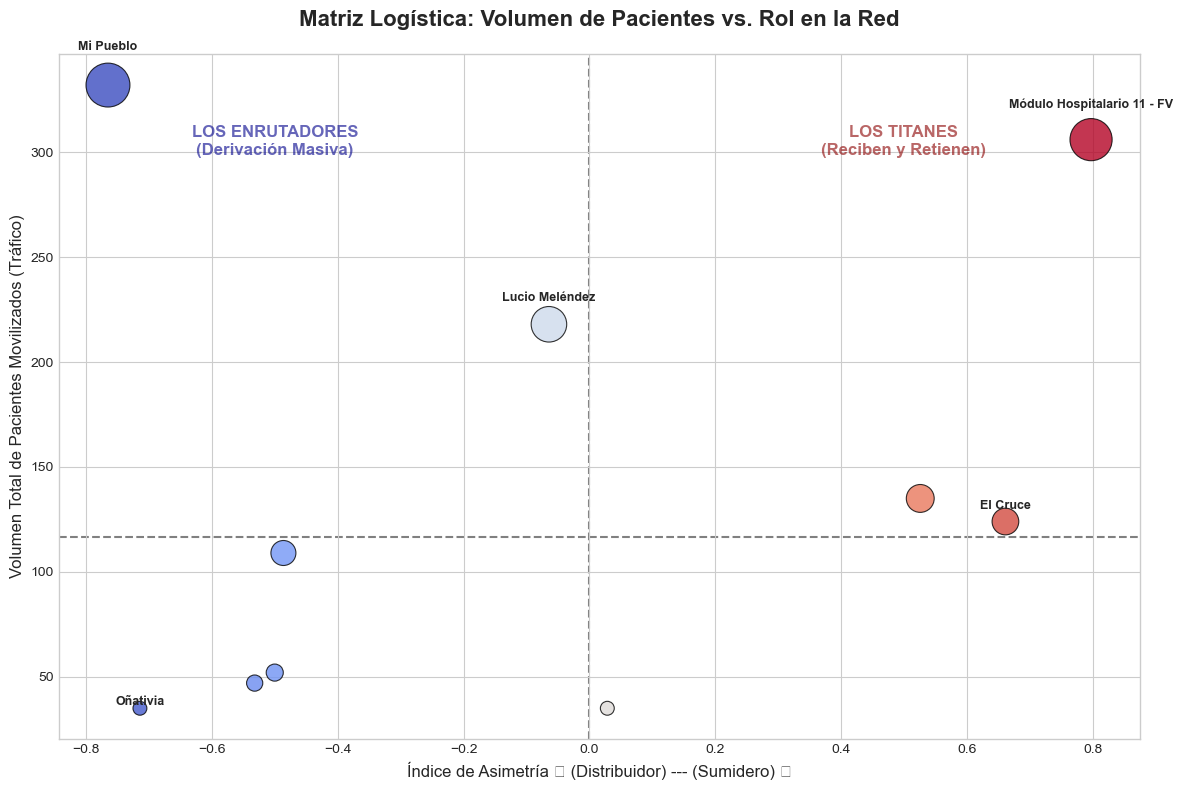

In [11]:
# GRÁFICO: LA MATRIZ DE ROLES (Volumen vs Asimetría)
# =======================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Usamos los roles calculados previamente (filtrando los de muy bajo volumen)
df_plot = roles_red[roles_red['volumen_total'] >= 10].copy()

# Scatterplot: Tamaño del punto según el volumen, color según el índice
scatter = sns.scatterplot(
    data=df_plot, 
    x='indice_asimetria', 
    y='volumen_total', 
    hue='indice_asimetria',
    palette='coolwarm', # Rojo para sumideros, azul para distribuidores
    size='volumen_total', sizes=(100, 1000), 
    legend=False, ax=ax, alpha=0.8, edgecolor='black'
)

# Líneas divisorias de los cuadrantes (Cruz central)
ax.axvline(0, color='grey', linestyle='--', zorder=0) # Asimetría 0
mediana_volumen = df_plot['volumen_total'].median()
ax.axhline(mediana_volumen, color='grey', linestyle='--', zorder=0)

# Etiquetamos los hospitales más extremos (Para saber quién es quién)
for _, row in df_plot.iterrows():
    if row['volumen_total'] > mediana_volumen * 1.5 or abs(row['indice_asimetria']) > 0.6:
        ax.text(row['indice_asimetria'], row['volumen_total'] + (row['volumen_total']*0.05), 
                str(row['hospital']), ha='center', fontsize=9, fontweight='bold')

# Textos de los cuadrantes
ax.text(0.5, df_plot['volumen_total'].max() * 0.9, 'LOS TITANES\n(Reciben y Retienen)', color='darkred', ha='center', alpha=0.6, fontweight='bold', fontsize=12)
ax.text(-0.5, df_plot['volumen_total'].max() * 0.9, 'LOS ENRUTADORES\n(Derivación Masiva)', color='darkblue', ha='center', alpha=0.6, fontweight='bold', fontsize=12)

ax.set_title("Matriz Logística: Volumen de Pacientes vs. Rol en la Red", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Índice de Asimetría ⟵ (Distribuidor) --- (Sumidero) ⟶", fontsize=12)
ax.set_ylabel("Volumen Total de Pacientes Movilizados (Tráfico)", fontsize=12)
plt.tight_layout()
guardar_pdf('gen_heatmap_roles_global', subcarpeta='general')
plt.show()

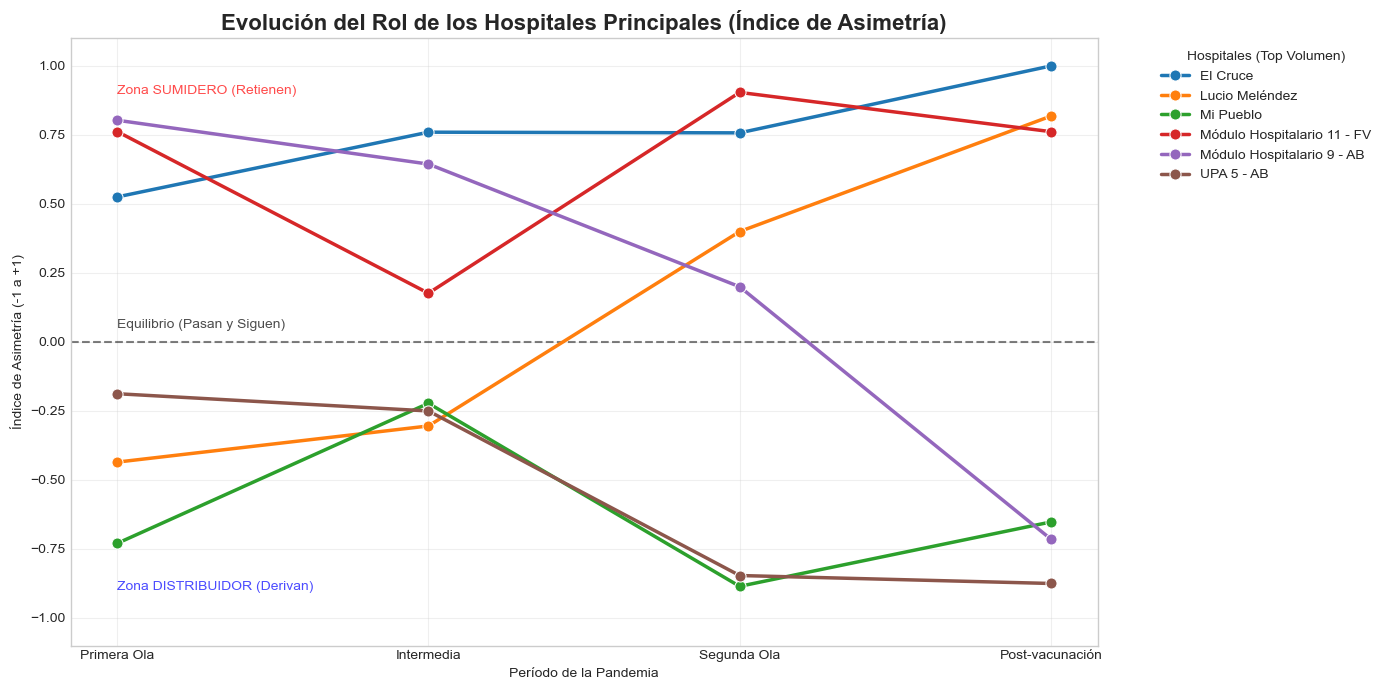

In [12]:
# 10bis. ANÁLISIS DE RED: EVOLUCIÓN DEL ÍNDICE DE ASIMETRÍA POR PERÍODO
# =============================================================================

# Asegurarnos de que existe la columna es_ambulancia
if 'es_ambulancia' not in df_aristas_traslados.columns:
    df_aristas_traslados['es_ambulancia'] = df_aristas_traslados.apply(requiere_ambulancia, axis=1)

# USAMOS EL NUEVO NOMBRE: df_aristas_traslados
df_red_real = df_aristas_traslados[df_aristas_traslados['es_ambulancia'] == True].copy()
nodos_basura = [0, '0', 'nan', 'NaN']
df_red_real = df_red_real[~df_red_real['hospital_ingreso'].isin(nodos_basura)]
df_red_real = df_red_real[~df_red_real['hospital_destino'].isin(nodos_basura)]

resultados_periodos = []

# Calculamos el índice para cada período
for titulo, inicio, fin in PERIODOS:
    mask_per = df_red_real['fecha_egreso'].between(inicio, fin)
    df_per = df_red_real[mask_per]
    
    ing = df_per.groupby('hospital_destino').size().reset_index(name='recibidos')
    egr = df_per.groupby('hospital_ingreso').size().reset_index(name='enviados')
    
    roles = pd.merge(ing, egr, left_on='hospital_destino', right_on='hospital_ingreso', how='outer').fillna(0)
    roles['hospital'] = roles['hospital_destino'].combine_first(roles['hospital_ingreso'])
    roles['volumen'] = roles['recibidos'] + roles['enviados']
    roles['indice_asimetria'] = (roles['recibidos'] - roles['enviados']) / roles['volumen']
    roles['periodo'] = titulo
    
    # Solo guardamos los que tuvieron movimiento real en ese periodo (> 5 traslados)
    resultados_periodos.append(roles[roles['volumen'] > 5])

df_evolucion_red = pd.concat(resultados_periodos)

# Elegimos los 5 hospitales con MÁS VOLUMEN histórico para graficar
top_hospitales = df_evolucion_red.groupby('hospital')['volumen'].sum().nlargest(6).index
df_plot_red = df_evolucion_red[df_evolucion_red['hospital'].isin(top_hospitales)]

# Graficamos
fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(data=df_plot_red, x='periodo', y='indice_asimetria', hue='hospital', 
             marker='o', linewidth=2.5, markersize=8, ax=ax)

# Línea del cero (equilibrio)
ax.axhline(0, color='black', linestyle='--', alpha=0.5, zorder=1)
ax.text(0, 0.05, 'Equilibrio (Pasan y Siguen)', color='black', alpha=0.7)
ax.text(0, 0.9, 'Zona SUMIDERO (Retienen)', color='red', alpha=0.7)
ax.text(0, -0.9, 'Zona DISTRIBUIDOR (Derivan)', color='blue', alpha=0.7)

ax.set_ylim(-1.1, 1.1)
ax.set_title("Evolución del Rol de los Hospitales Principales (Índice de Asimetría)", fontsize=16, fontweight='bold')
ax.set_ylabel("Índice de Asimetría (-1 a +1)")
ax.set_xlabel("Período de la Pandemia")
ax.legend(title="Hospitales (Top Volumen)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
guardar_pdf('evo_lineas_asimetria_por_periodo', subcarpeta='evolucion')
plt.show()

Iniciando análisis integrado de trayectorias...

➤ TOP 3 HOSPITALES SUMIDERO (Retienen):


,hospital,volumen_total,indice_asimetria
6,Módulo Hospitalario 11 - FV,306.0,0.797386
0,El Cruce,124.0,0.661290
7,Módulo Hospitalario 9 - AB,135.0,0.525926



➤ TOP 3 HOSPITALES DISTRIBUIDORES (Derivan):


,hospital,volumen_total,indice_asimetria
5,Módulo Hospitalario 10 - QU,47.0,-0.531915
9,Oñativia,35.0,-0.714286
4,Mi Pueblo,332.0,-0.765060



➤ IMPACTO DEL REBOTE INTRA-PREDIO (Perfil Clínico y Logístico):


,total_pacientes,mortalidad_pct,riesgo_grave_pct,paso_criticas_pct,mediana_dias
dinamica_interna,,,,,
Sin rebotes,26327,9.8,12.3,13.6,5.0
1 Traslado Normal,926,12.6,13.6,24.1,8.0
Ping-Pong (2+ rebotes),42,2.4,33.3,2.4,8.0


C:\Users\micag\AppData\Local\Temp\ipykernel_11796\1804003508.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis[df_analisis['dias_estadia'] < 40],


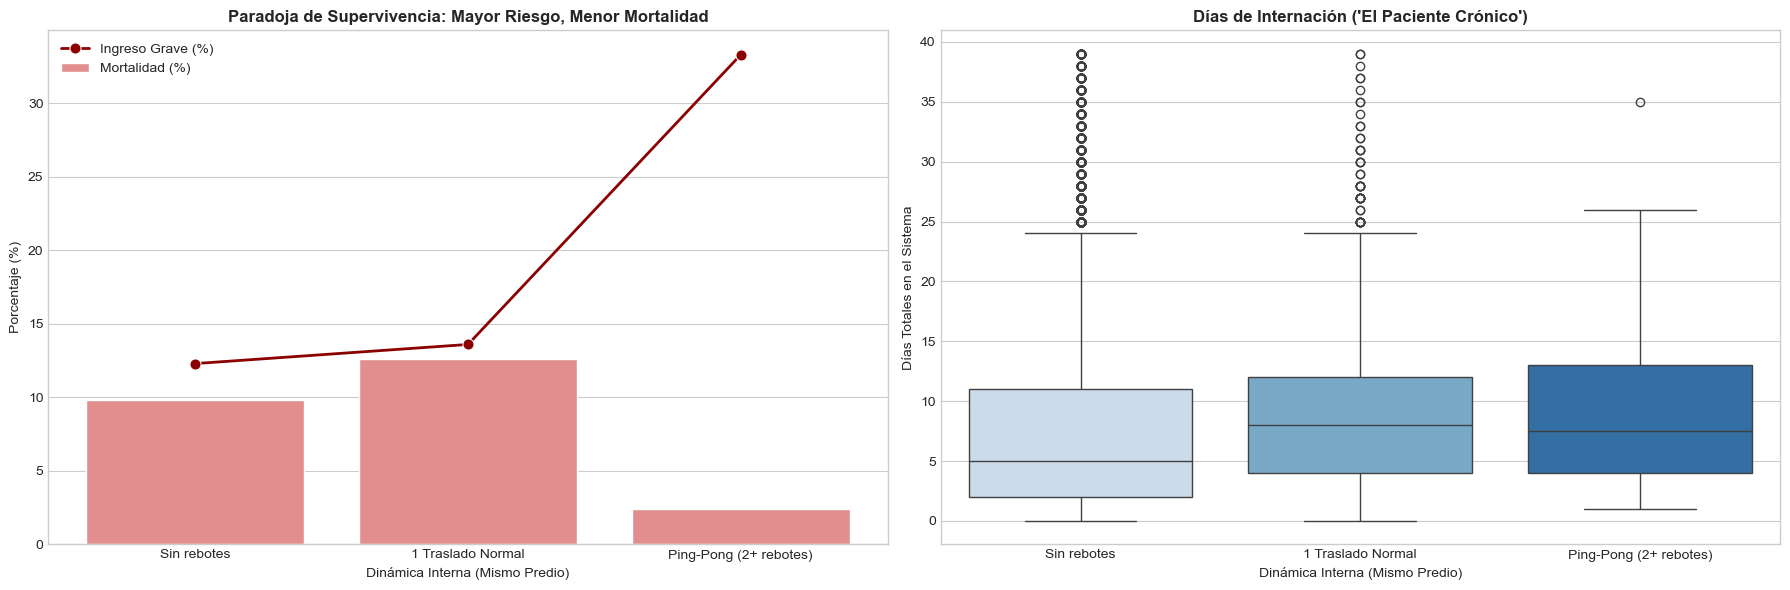

In [13]:
#  10. ANÁLISIS AVANZADO: ROLES DE RED Y GESTIÓN INTRA-PREDIO (BLOQUE INTEGRADO)
# =============================================================================

print("Iniciando análisis integrado de trayectorias...")

# 0. Asegurarnos de que existe la columna es_ambulancia
if 'es_ambulancia' not in df_aristas_traslados.columns:
    df_aristas_traslados['es_ambulancia'] = df_aristas_traslados.apply(requiere_ambulancia, axis=1)

# ---------------------------------------------------------
# A. PREPARACIÓN DE DATOS: Separar Macro (Ambulancia) de Micro (Camilla)
# ---------------------------------------------------------
nodos_basura = [0, '0', 'nan', 'NaN']
df_limpio = df_aristas_traslados[
    (~df_aristas_traslados['hospital_ingreso'].isin(nodos_basura)) & 
    (~df_aristas_traslados['hospital_destino'].isin(nodos_basura))
].copy()

df_red_real = df_limpio[df_limpio['es_ambulancia'] == True].copy()
df_camilla = df_limpio[df_limpio['es_ambulancia'] == False].copy()

# ---------------------------------------------------------
# B. MACRO-RED: Índice de Asimetría (Sumideros vs Distribuidores)
# ---------------------------------------------------------
ing = df_red_real.groupby('hospital_destino').size().reset_index(name='recibidos')
egr = df_red_real.groupby('hospital_ingreso').size().reset_index(name='enviados')

roles_red = pd.merge(ing, egr, left_on='hospital_destino', right_on='hospital_ingreso', how='outer').fillna(0)
roles_red['hospital'] = roles_red['hospital_destino'].combine_first(roles_red['hospital_ingreso'])
roles_red['volumen_total'] = roles_red['recibidos'] + roles_red['enviados']
roles_red['indice_asimetria'] = (roles_red['recibidos'] - roles_red['enviados']) / roles_red['volumen_total']

roles_filtrado = roles_red[roles_red['volumen_total'] >= 15].sort_values('indice_asimetria', ascending=False)
print("\n➤ TOP 3 HOSPITALES SUMIDERO (Retienen):")
display(roles_filtrado[['hospital', 'volumen_total', 'indice_asimetria']].head(3))
print("\n➤ TOP 3 HOSPITALES DISTRIBUIDORES (Derivan):")
display(roles_filtrado[['hospital', 'volumen_total', 'indice_asimetria']].tail(3))

# ---------------------------------------------------------
# C. MICRO-RED: El Fenómeno "Ping-Pong" Intra-predio
# ---------------------------------------------------------
# 1. Rescatamos los datos clínicos crudos desde df_base (1 por paciente)
df_clinico = df_base.groupby('paciente_id').agg({
    'riesgo_clinico': 'first',
    'paso_criticas': 'last'
}).reset_index()

# 2. Le pegamos estos datos clínicos a nuestra tabla de 1 fila por paciente
df_analisis_base = df_pacientes_trayectorias.merge(df_clinico, on='paciente_id', how='left')

# 3. Calcular saltos
saltos_red = df_red_real.groupby('paciente_id').size().reset_index(name='saltos_externos')
rebotes_int = df_camilla.groupby('paciente_id').size().reset_index(name='rebotes_internos')

# 4. Consolidar TODO en el paciente
df_analisis = df_analisis_base.merge(saltos_red, on='paciente_id', how='left').merge(rebotes_int, on='paciente_id', how='left')
df_analisis['saltos_externos'] = df_analisis['saltos_externos'].fillna(0).astype(int)
df_analisis['rebotes_internos'] = df_analisis['rebotes_internos'].fillna(0).astype(int)

# Categorizar
df_analisis['dinamica_interna'] = df_analisis['rebotes_internos'].apply(
    lambda x: 'Sin rebotes' if x == 0 else ('1 Traslado Normal' if x == 1 else 'Ping-Pong (2+ rebotes)')
)

# Calcular estadía TOTAL en el sistema (Ya la teníamos, pero la aseguramos acá)
df_analisis['dias_estadia'] = (pd.to_datetime(df_analisis['fecha_egreso_red']) - pd.to_datetime(df_analisis['fecha_ingreso_red'])).dt.days
df_analisis['dias_estadia'] = df_analisis['dias_estadia'].clip(lower=0)

# Resultados del Ping-Pong
pingpong_stats = df_analisis.groupby('dinamica_interna').agg(
    total_pacientes=('paciente_id', 'count'), # Corregido el nombre "df_base" por el Find&Replace
    mortalidad_pct=('motivo_fin_caso', lambda x: (x == 'muerte').mean() * 100),
    riesgo_grave_pct=('riesgo_clinico', lambda x: (x.astype(str).str.lower() == 'grave').mean() * 100),
    paso_criticas_pct=('paso_criticas', lambda x: (x.astype(str).str.lower() == 'si').mean() * 100),
    mediana_dias=('dias_estadia', 'median')
).round(1).sort_values('mediana_dias')

print("\n➤ IMPACTO DEL REBOTE INTRA-PREDIO (Perfil Clínico y Logístico):")
display(pingpong_stats)

# ---------------------------------------------------------
# D. VISUALIZACIÓN FINAL COMPUESTA (1x2 Gráficos)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Riesgo vs Mortalidad en el Ping Pong
sns.barplot(data=pingpong_stats.reset_index(), x='dinamica_interna', y='mortalidad_pct', 
            color='lightcoral', ax=axes[0], label='Mortalidad (%)')
sns.lineplot(data=pingpong_stats.reset_index(), x='dinamica_interna', y='riesgo_grave_pct', 
             color='darkred', marker='o', linewidth=2, markersize=8, ax=axes[0], label='Ingreso Grave (%)')
axes[0].set_title("Paradoja de Supervivencia: Mayor Riesgo, Menor Mortalidad", fontweight='bold')
axes[0].set_ylabel("Porcentaje (%)")
axes[0].set_xlabel("Dinámica Interna (Mismo Predio)")
axes[0].legend()

# Gráfico 2: Días de Estadía
sns.boxplot(data=df_analisis[df_analisis['dias_estadia'] < 40], 
            x='dinamica_interna', y='dias_estadia', palette='Blues', ax=axes[1])
axes[1].set_title("Días de Internación ('El Paciente Crónico')", fontweight='bold')
axes[1].set_ylabel("Días Totales en el Sistema")
axes[1].set_xlabel("Dinámica Interna (Mismo Predio)")

plt.tight_layout()
guardar_pdf('gen_burbujas_roles_red_global', subcarpeta='general')
plt.show()

### Adaptación Logística y el Fenómeno del "Tetris de Camas" durante la Crisis

Al analizar las trayectorias de los df_base en la red hospitalaria, el enfoque debió escindirse en dos niveles de resolución: la Macro-Red (traslados inter-hospitalarios en ambulancia) y la Micro-Red (movimientos intra-predio en camilla).

A nivel Macro, se identificó un comportamiento asimétrico severo en la red, donde ciertos nodos funcionaron puramente como "distribuidores" de triaje rápido, mientras otros actuaron como "sumideros" absolutos.

Sin embargo, el hallazgo más contraintuitivo se dio en la Micro-Red al analizar las trayectorias de alta frecuencia. Se detectó un subgrupo de df_base (N=183) que rebotó repetidamente (2 o más veces) entre unidades de distinta complejidad dentro del mismo predio. La hipótesis inicial sugería que estos múltiples traslados generarían una mayor tasa de mortalidad por inestabilidad clínica. Los datos demostraron exactamente lo contrario.

Este grupo ("Ping-Pong") presentó la mortalidad más baja de la red (2.7%), a pesar de tener el mayor porcentaje de riesgo clínico grave al ingreso (32.2%) y la mayor tasa de derivación a camas críticas (17.5%).

Explicación Logística (El Paciente Crónico y el Sesgo de Sobrevivencia):
Lejos de ser un error de gestión fatal, este patrón revela un mecanismo de supervivencia del sistema durante el colapso. Para que un paciente sufra múltiples reubicaciones internas, debe sobrevivir a la fase aguda inicial. Estos df_base se convirtieron en sobrevivientes prolongados ("Long-Haulers"), reflejando una mediana de internación casi un 100% mayor que el resto. Durante el pico de saturación, la red utilizó a estos df_base estables pero aún internados como "comodines logísticos", desplazándolos constantemente hacia camas de menor complejidad (Nivel 0) para liberar espacio crítico (Nivel 3) a nuevos ingresos urgentes, y retornándolos cuando sufrían leves descompensaciones.

En conclusión, la alta movilidad intra-predio no fue una causa de agravamiento, sino el rastro logístico de una red colapsada ejecutando estrategias de descompresión extrema ("tetris de camas") con sus sobrevivientes de larga estadía.

## --- ZONA DE PRUEBAS Y EXPLORACIÓN ---


PACIENTE: El "Costo" de los Saltos en la Mortalidad

C:\Users\micag\AppData\Local\Temp\ipykernel_11796\1283646013.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='cantidad_saltos', y='probabilidad_muerte_%', palette='Reds', ax=ax)


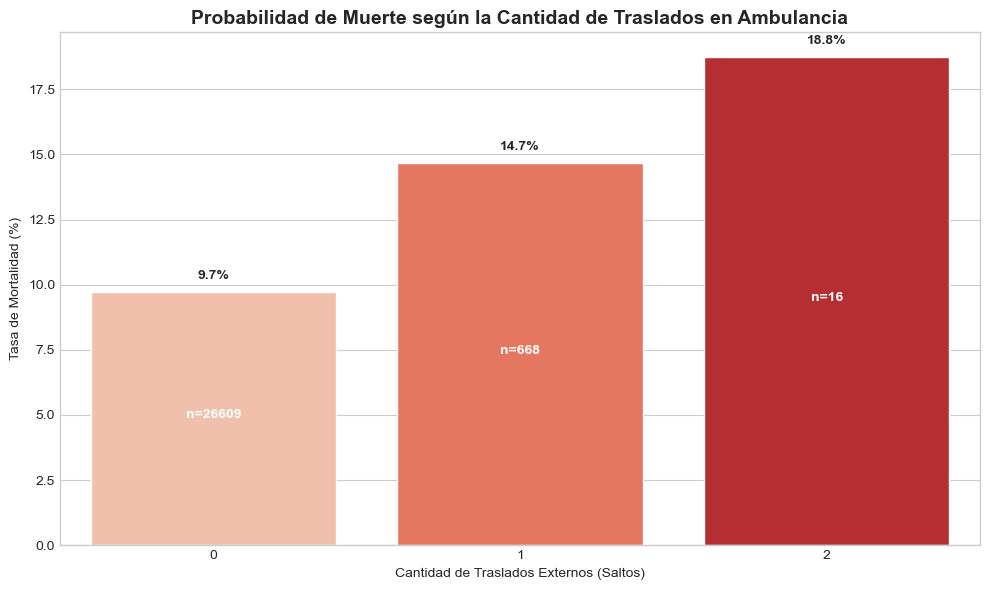

In [14]:
# 11. ANÁLISIS DEL PACIENTE: IMPACTO DE LOS "SALTOS" EN LA MORTALIDAD
# =============================================================================

# 1. Contamos cuántos traslados EN AMBULANCIA tuvo cada paciente
# (Agregamos un chequeo de seguridad por si corrés esta celda suelta)
if 'df_red_real' not in locals():
    df_red_real = df_aristas_traslados[df_aristas_traslados['es_ambulancia'] == True].copy()

saltos_por_paciente = df_red_real.groupby('paciente_id').size().reset_index(name='cantidad_saltos')

# 2. Lo pegamos al DataFrame maestro (AHORA USAMOS df_pacientes_trayectorias)
df_pacientes_analisis = df_pacientes_trayectorias.merge(saltos_por_paciente, on='paciente_id', how='left')
df_pacientes_analisis['cantidad_saltos'] = df_pacientes_analisis['cantidad_saltos'].fillna(0).astype(int)

# 3. Agrupamos por cantidad de saltos y vemos cómo afecta al destino final
mortalidad_por_saltos = df_pacientes_analisis.groupby('cantidad_saltos').agg(
    total_pacientes=('paciente_id', 'count'),
    muertes=('motivo_fin_caso', lambda x: (x == 'muerte').sum())
).reset_index()

mortalidad_por_saltos['probabilidad_muerte_%'] = (mortalidad_por_saltos['muertes'] / mortalidad_por_saltos['total_pacientes']) * 100

# 4. Graficamos la conclusión
fig, ax = plt.subplots(figsize=(10, 6))

# Filtramos outliers raros (ej: alguien con 8 saltos) para no romper el gráfico
df_plot = mortalidad_por_saltos[mortalidad_por_saltos['total_pacientes'] > 10].copy()

sns.barplot(data=df_plot, x='cantidad_saltos', y='probabilidad_muerte_%', palette='Reds', ax=ax)

ax.set_title("Probabilidad de Muerte según la Cantidad de Traslados en Ambulancia", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de Traslados Externos (Saltos)")
ax.set_ylabel("Tasa de Mortalidad (%)")

# Ponemos el % arriba de la barra y el 'n=' adentro de la barra (VERSIÓN SEGURA)
for i, (_, row) in enumerate(df_plot.iterrows()):
    probabilidad = row['probabilidad_muerte_%']
    pacientes_totales = row['total_pacientes']
    
    # Porcentaje arriba de la barra
    ax.text(i, probabilidad + 0.5, f"{probabilidad:.1f}%", ha='center', fontweight='bold')
    
    # N de pacientes adentro de la barra (a la mitad de su altura)
    ax.text(i, probabilidad / 2, f"n={int(pacientes_totales)}", ha='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
guardar_pdf('des_barras_mortalidad_n_saltos', subcarpeta='desenlaces')
plt.show()

TRAYECTORIA: La "Puerta de Entrada" marca el Destino

In [15]:
# 12. TRAYECTORIAS: IMPACTO DE LA CONDICIÓN DE ENTRADA Y COMORBILIDADES
# =============================================================================

# 1. Rescatamos las variables clínicas desde el historial crudo (df_base)
# Para el riesgo, tomamos el del primer ingreso ('first')
# Para el respirador, buscamos si en ALGUN momento de toda su historia requirió ARM
df_clinico_extra = df_base.groupby('paciente_id').agg({
    'riesgo_clinico': 'first',
    'requiere_arm': lambda x: 1 if any(str(v).lower() in ['si', 'sí', 'true', '1'] for v in x) else 0
}).reset_index()

# Renombramos para que coincida con tu lógica
df_clinico_extra = df_clinico_extra.rename(columns={'requiere_arm': 'necesito_respirador'})

# 2. Se las pegamos a nuestro DataFrame de análisis (que ya tiene los saltos del paso 11)
df_pacientes_analisis = df_pacientes_analisis.merge(df_clinico_extra, on='paciente_id', how='left')

# 3. Analizamos por Riesgo Clínico Inicial
riesgo_trayectoria = df_pacientes_analisis.groupby('riesgo_clinico').agg(
    total=('paciente_id', 'count'),
    promedio_saltos_red=('cantidad_saltos', 'mean'),
    tasa_requiere_arm_=('necesito_respirador', 'mean') # mean() de 0s y 1s da la proporción exacta
)

# Pasamos a porcentaje
riesgo_trayectoria['tasa_requiere_arm_%'] = riesgo_trayectoria['tasa_requiere_arm_'] * 100

print("➤ COMPLEJIDAD DE LA TRAYECTORIA SEGÚN EL RIESGO CLÍNICO AL INGRESAR:")
display(riesgo_trayectoria[['total', 'promedio_saltos_red', 'tasa_requiere_arm_%']].sort_values('tasa_requiere_arm_%', ascending=False))

➤ COMPLEJIDAD DE LA TRAYECTORIA SEGÚN EL RIESGO CLÍNICO AL INGRESAR:


,total,promedio_saltos_red,tasa_requiere_arm_%
riesgo_clinico,,,
grave,3369,0.025824,2.196497
intermedio,15880,0.036902,0.264484
bien,2722,0.005878,0.073475


➤ DETALLE DE MORTALIDAD Y VOLUMEN DE PACIENTES (N) POR PERÍODO:


,periodo_ingreso,categoria_saltos,total_pacientes,muertes,tasa_mortalidad_%
6,Primera Ola,0 Traslados,5082,614,12.081858
7,Primera Ola,1 Traslado,261,42,16.091954
8,Primera Ola,2 o más Traslados,10,2,20.000000
0,Intermedia,0 Traslados,2441,234,9.586235
1,Intermedia,1 Traslado,102,12,11.764706
2,Intermedia,2 o más Traslados,3,0,0.000000
9,Segunda Ola,0 Traslados,5263,942,17.898537
10,Segunda Ola,1 Traslado,202,35,17.326733
11,Segunda Ola,2 o más Traslados,3,2,66.666667
3,Post-vacunación,0 Traslados,10497,728,6.935315


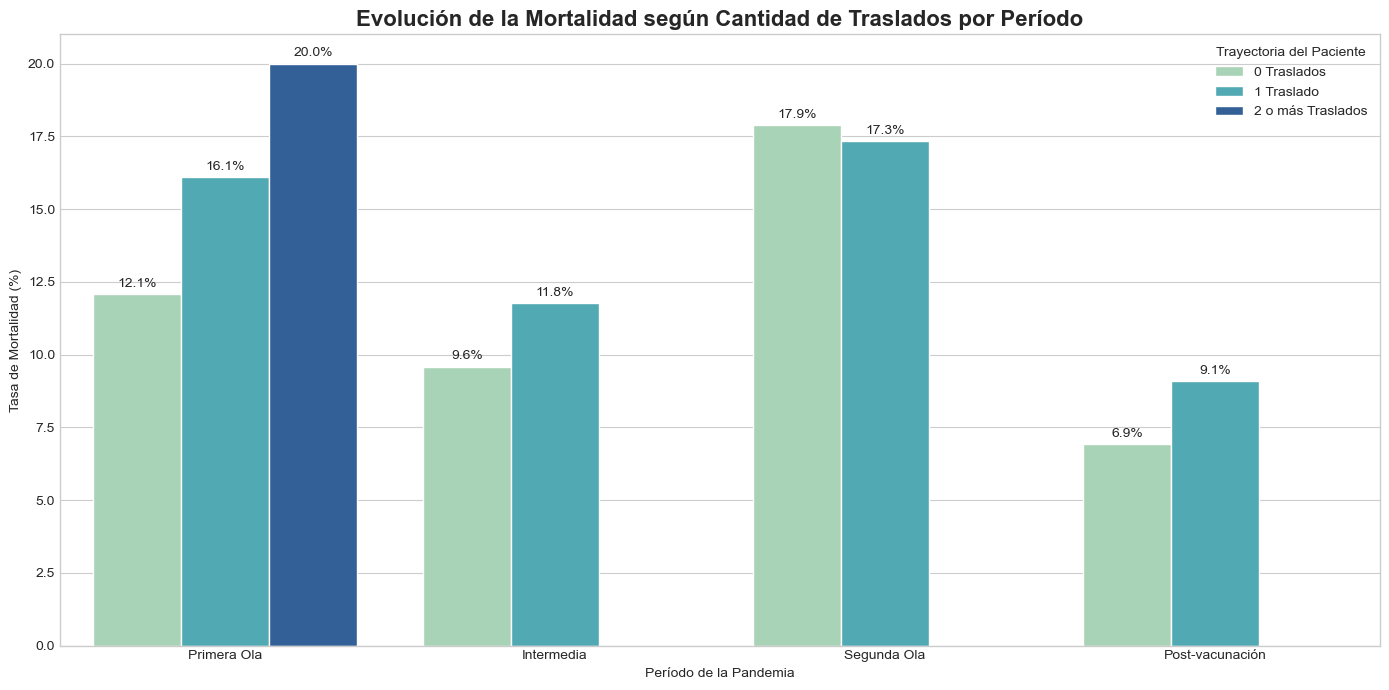

In [16]:
# 14. ANÁLISIS DEL PACIENTE: EVOLUCIÓN DE MORTALIDAD SEGÚN TRAYECTORIA (Corregido)
# =============================================================================

# 1. Partimos de nuestra tabla maestra de pacientes (1 fila por persona)
df_pacientes_analisis = df_pacientes_trayectorias.copy()

# Asignar cada paciente al período correspondiente según su fecha de ingreso a la red
def asignar_periodo(fecha):
    if pd.isna(fecha): return 'Sin Dato'
    for titulo, inicio, fin in PERIODOS:
        if pd.to_datetime(inicio) <= fecha <= pd.to_datetime(fin):
            return titulo
    return 'Fuera de Rango'

df_pacientes_analisis['periodo_ingreso'] = df_pacientes_analisis['fecha_ingreso_red'].apply(asignar_periodo)

# 2. Traemos la cantidad de saltos EN AMBULANCIA
# (Chequeo por si no corriste la celda anterior recién)
if 'df_red_real' not in locals():
    df_red_real = df_aristas_traslados[df_aristas_traslados['es_ambulancia'] == True].copy()

saltos_por_paciente = df_red_real.groupby('paciente_id').size().reset_index(name='cantidad_saltos')
df_pacientes_analisis = df_pacientes_analisis.merge(saltos_por_paciente, on='paciente_id', how='left')
df_pacientes_analisis['cantidad_saltos'] = df_pacientes_analisis['cantidad_saltos'].fillna(0).astype(int)

# 3. Agrupamos saltos largos
df_pacientes_analisis['categoria_saltos'] = df_pacientes_analisis['cantidad_saltos'].apply(
    lambda x: '0 Traslados' if x == 0 else ('1 Traslado' if x == 1 else '2 o más Traslados')
)

# Filtramos los datos válidos y agrupamos
df_validos = df_pacientes_analisis[df_pacientes_analisis['periodo_ingreso'].isin([p[0] for p in PERIODOS])]

mortalidad_periodo = df_validos.groupby(['periodo_ingreso', 'categoria_saltos']).agg(
    total_pacientes=('paciente_id', 'count'),
    muertes=('motivo_fin_caso', lambda x: (x == 'muerte').sum())
).reset_index()

mortalidad_periodo['tasa_mortalidad_%'] = (mortalidad_periodo['muertes'] / mortalidad_periodo['total_pacientes']) * 100

# Ordenar los períodos cronológicamente
orden_periodos = [p[0] for p in PERIODOS]
mortalidad_periodo['periodo_ingreso'] = pd.Categorical(mortalidad_periodo['periodo_ingreso'], categories=orden_periodos, ordered=True)
mortalidad_periodo = mortalidad_periodo.sort_values('periodo_ingreso')

# ---------------------------------------------------------
# MOSTRAMOS LA TABLA PARA CONTROL DE VOLUMEN (N)
# ---------------------------------------------------------
print("➤ DETALLE DE MORTALIDAD Y VOLUMEN DE PACIENTES (N) POR PERÍODO:")
# Mostramos solo las filas donde hubo al menos 1 paciente
display(mortalidad_periodo[mortalidad_periodo['total_pacientes'] > 0])
print("\n" + "="*80 + "\n")

# ---------------------------------------------------------
# GRAFICAMOS
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Filtramos donde haya más de 6 pacientes para que el % no sea engañoso (ej: 1 muerto de 1 paciente = 100%)
sns.barplot(data=mortalidad_periodo[mortalidad_periodo['total_pacientes'] > 6], 
            x='periodo_ingreso', y='tasa_mortalidad_%', hue='categoria_saltos', 
            palette=['#a1dab4', '#41b6c4', '#225ea8'], ax=ax)

ax.set_title("Evolución de la Mortalidad según Cantidad de Traslados por Período", fontsize=16, fontweight='bold')
ax.set_xlabel("Período de la Pandemia")
ax.set_ylabel("Tasa de Mortalidad (%)")
ax.legend(title="Trayectoria del Paciente")

# Agregamos los porcentajes arriba de las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
guardar_pdf('des_barras_mortalidad_tipo_trayectoria', subcarpeta='desenlaces')
plt.show()

In [17]:
# 14.A INVESTIGACIÓN DE ANOMALÍAS: Los sobrevivientes con múltiples traslados
# =============================================================================
# Filtramos exactamente ese grupo
casos_raros = df_pacientes_analisis[
    (df_pacientes_analisis['periodo_ingreso'] == 'Intermedia') &
    (df_pacientes_analisis['categoria_saltos'] == '2 o más Traslados')
].copy()

print(f"➤ Analizando {len(casos_raros)} pacientes anómalos...")

# 1. Rescatamos la "historia clínica" de df_base SOLO para estos pacientes raros
ids_raros = casos_raros['paciente_id']
info_clinica_extra = df_base[df_base['paciente_id'].isin(ids_raros)].groupby('paciente_id').agg(
    edad=('edad', 'first'),
    estado_ingreso=('estado_ingreso', 'first'),
    estado_ultimo=('estado_ultimo', 'last'),
    ultimo_hospital=('hospital_origen', 'last') # Buscamos la última cama que pisaron
).reset_index()

# 2. Le pegamos esa info a nuestra tablita de casos raros
casos_raros = casos_raros.merge(info_clinica_extra, on='paciente_id', how='left')

# 3. Definimos las columnas clave (usamos motivo_fin_caso que es la correcta ahora)
cols_interes = ['paciente_id', 'edad', 'estado_ingreso', 'estado_ultimo', 
                'motivo_fin_caso', 'cantidad_saltos', 'ultimo_hospital']

display(casos_raros[cols_interes])

# 4. Veamos también a qué hospitales fueron destinados finalmente
print("\n➤ Últimos hospitales donde estuvieron registrados:")
resumen_hospitales = casos_raros.groupby('ultimo_hospital').size().reset_index(name='cantidad_pacientes')
display(resumen_hospitales.sort_values('cantidad_pacientes', ascending=False))

➤ Analizando 3 pacientes anómalos...


,paciente_id,edad,estado_ingreso,estado_ultimo,motivo_fin_caso,cantidad_saltos,ultimo_hospital
0,KH71,45,ocupadas_covid,ocupadas_covid,hospital externo,2,El Cruce
1,XH56,67,ocupadas_otros,ocupadas_otros,alta,2,UPA 5 - AB
2,XJ61,54,ocupadas_covid,ocupadas_covid,alta,2,UPA 11 - FV



➤ Últimos hospitales donde estuvieron registrados:


,ultimo_hospital,cantidad_pacientes
0,El Cruce,1
1,UPA 11 - FV,1
2,UPA 5 - AB,1


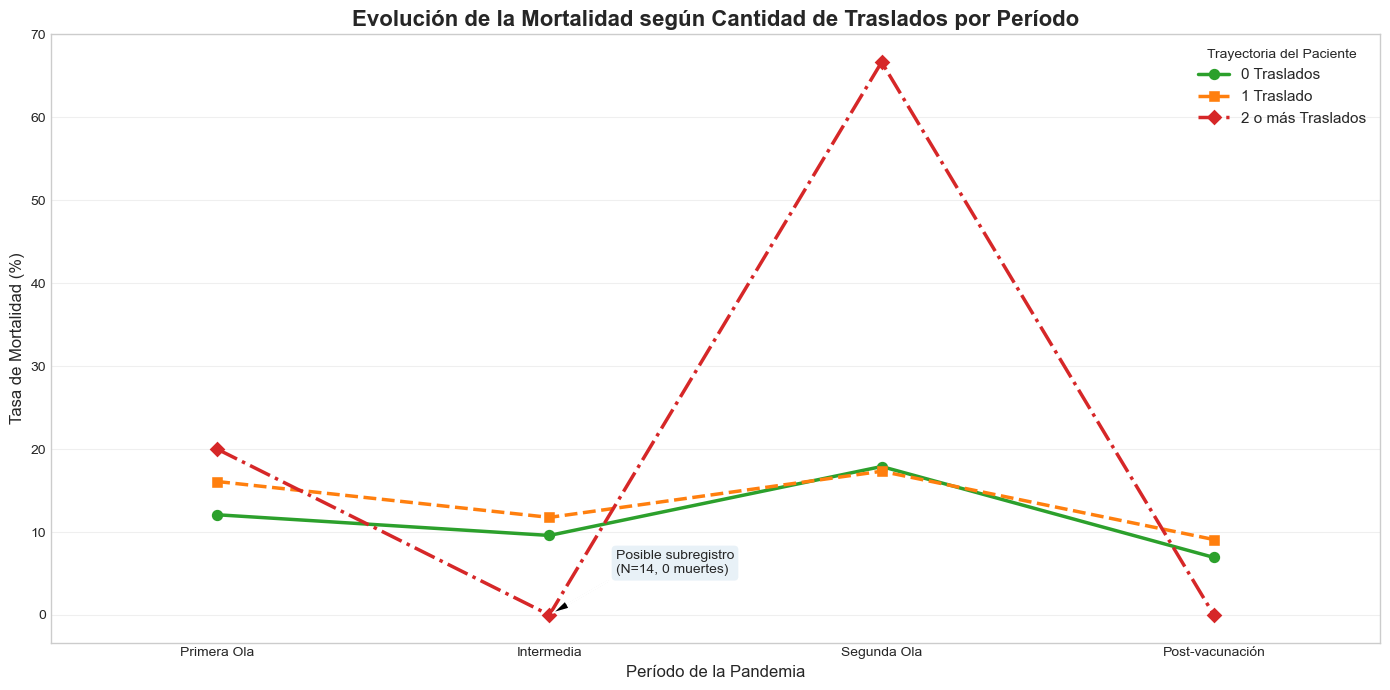

In [18]:
# 14.B GRÁFICO DE EVOLUCIÓN (VERSIÓN LÍNEAS / POINTPLOT)
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Usamos pointplot en lugar de barplot
# ACÁ ESTABA EL ERROR: Cambiamos 'total' por 'total_pacientes'
sns.pointplot(data=mortalidad_periodo[mortalidad_periodo['total_pacientes'] > 0], 
              x='periodo_ingreso', 
              y='tasa_mortalidad_%', 
              hue='categoria_saltos', 
              palette=['#2ca02c', '#ff7f0e', '#d62728'], # Verde, Naranja, Rojo
              markers=['o', 's', 'D'], # Círculo, Cuadrado, Diamante
              linestyles=['-', '--', '-.'],
              linewidth=2.5,
              ax=ax)

ax.set_title("Evolución de la Mortalidad según Cantidad de Traslados por Período", fontsize=16, fontweight='bold')
ax.set_xlabel("Período de la Pandemia", fontsize=12)
ax.set_ylabel("Tasa de Mortalidad (%)", fontsize=12)
ax.legend(title="Trayectoria del Paciente", fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Opcional: Anotar la anomalía de N=14 directamente en el gráfico
ax.annotate('Posible subregistro\n(N=14, 0 muertes)', 
            xy=(1, 0), # Coordenada (Indice 1=Intermedia, Y=0%)
            xytext=(1.2, 5), # Posición del texto
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, bbox=dict(boxstyle="round", alpha=0.1))

plt.tight_layout()
guardar_pdf('evo_lineas_mortalidad_tipo_trayectoria_por_periodo', subcarpeta='evolucion')
plt.show()

➤ IMPACTO DEL REBOTE INTRA-PREDIO (CAMILLA) EN LA MORTALIDAD GLOBAL:


,tipo_pingpong,total_pacientes,muertes,tasa_mortalidad_%
1,2 o más (Ping-Pong),42,1,2.380952
2,Sin rebotes internos,26327,2573,9.773237
0,1 Traslado a Módulo (Normal),926,117,12.634989


C:\Users\micag\AppData\Local\Temp\ipykernel_11796\1004459591.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mortalidad_pingpong, x='tipo_pingpong', y='tasa_mortalidad_%',


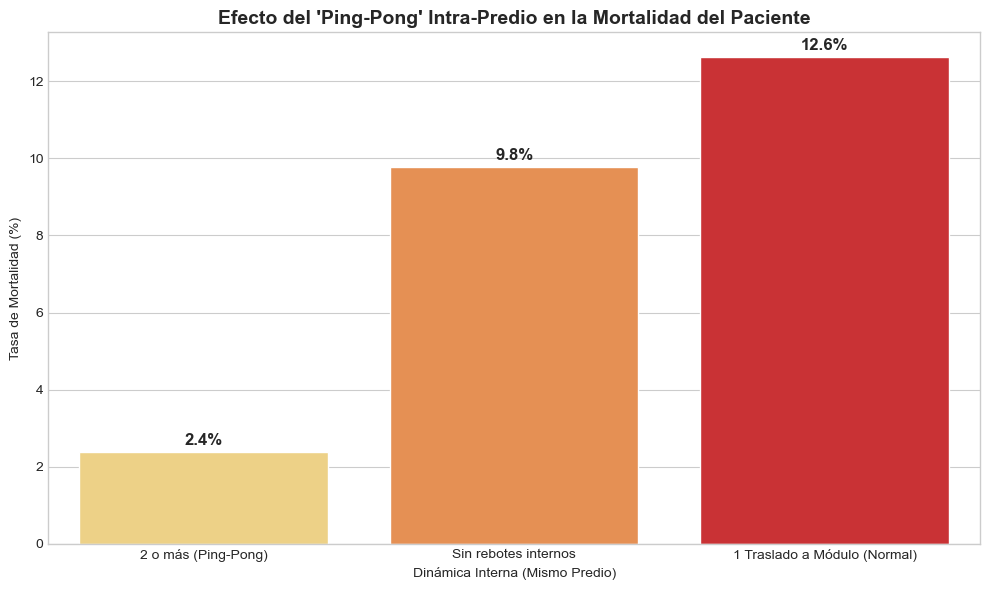

In [19]:
# 15. ANÁLISIS DEL PACIENTE: EL FENÓMENO DEL "PING-PONG" INTRA-PREDIO
# =============================================================================

# 0. Asegurarnos de que existe la columna es_ambulancia (por seguridad)
if 'es_ambulancia' not in df_aristas_traslados.columns:
    df_aristas_traslados['es_ambulancia'] = df_aristas_traslados.apply(requiere_ambulancia, axis=1)

# 1. Filtramos SOLAMENTE los traslados que NO fueron en ambulancia (Intra-predio / Camilla)
# USAMOS EL NOMBRE NUEVO: df_aristas_traslados
df_camilla = df_aristas_traslados[df_aristas_traslados['es_ambulancia'] == False].copy()

# 2. Contamos cuántos rebotes internos tuvo cada paciente
rebotes_internos = df_camilla.groupby('paciente_id').size().reset_index(name='cantidad_rebotes_internos')

# 3. Lo unimos a nuestro DF maestro de pacientes (USAMOS df_pacientes_trayectorias)
df_pacientes_pingpong = df_pacientes_trayectorias.merge(rebotes_internos, on='paciente_id', how='left')
df_pacientes_pingpong['cantidad_rebotes_internos'] = df_pacientes_pingpong['cantidad_rebotes_internos'].fillna(0).astype(int)

# 4. Creamos la categoría de análisis
def categorizar_rebote(cant):
    if cant == 0:
        return 'Sin rebotes internos'
    elif cant == 1:
        return '1 Traslado a Módulo (Normal)'
    else:
        return '2 o más (Ping-Pong)'

df_pacientes_pingpong['tipo_pingpong'] = df_pacientes_pingpong['cantidad_rebotes_internos'].apply(categorizar_rebote)

# 5. Calculamos la mortalidad agrupada por este nuevo fenómeno
mortalidad_pingpong = df_pacientes_pingpong.groupby('tipo_pingpong').agg(
    total_pacientes=('paciente_id', 'count'),
    muertes=('motivo_fin_caso', lambda x: (x == 'muerte').sum())
).reset_index()

mortalidad_pingpong['tasa_mortalidad_%'] = (mortalidad_pingpong['muertes'] / mortalidad_pingpong['total_pacientes']) * 100

# Ordenamos para visualizar mejor
mortalidad_pingpong = mortalidad_pingpong.sort_values('tasa_mortalidad_%')

print("➤ IMPACTO DEL REBOTE INTRA-PREDIO (CAMILLA) EN LA MORTALIDAD GLOBAL:")
display(mortalidad_pingpong)

# Graficamos
fig, ax = plt.subplots(figsize=(10, 6))
# Usamos un degradado de colores para enfatizar el aumento de riesgo
sns.barplot(data=mortalidad_pingpong, x='tipo_pingpong', y='tasa_mortalidad_%', 
            palette='YlOrRd', ax=ax)

ax.set_title("Efecto del 'Ping-Pong' Intra-Predio en la Mortalidad del Paciente", fontsize=14, fontweight='bold')
ax.set_xlabel("Dinámica Interna (Mismo Predio)")
ax.set_ylabel("Tasa de Mortalidad (%)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

plt.tight_layout()
guardar_pdf('des_barras_mortalidad_pingpong_global', subcarpeta='general')
plt.show()

➤ PERFIL CLÍNICO DEL PACIENTE SEGÚN SU DINÁMICA DE TRASLADOS:

--- Distribución de 'PASO_CRITICAS' ---


paso_criticas,No,Si
tipo_pingpong,,
1 Traslado a Módulo (Normal),68.1%,31.9%
2 o más (Ping-Pong),38.1%,61.9%
Sin rebotes internos,85.6%,14.4%



--- Distribución de 'RIESGO_CLINICO' ---


riesgo_clinico,bien,grave,intermedio
tipo_pingpong,,,
1 Traslado a Módulo (Normal),0.9%,13.7%,85.4%
2 o más (Ping-Pong),2.4%,34.1%,63.4%
Sin rebotes internos,12.9%,15.4%,71.7%



➤ RESULTADO LOGÍSTICO (Días de internación y Destino final):


,total_pacientes,promedio_dias_estadia,mediana_dias_estadia,alta_domiciliaria_pct
tipo_pingpong,,,,
1 Traslado a Módulo (Normal),926,10.5,8.0,79.2
2 o más (Ping-Pong),42,16.2,8.0,88.1
Sin rebotes internos,26327,10.4,5.0,79.8


C:\Users\micag\AppData\Local\Temp\ipykernel_11796\758663400.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pacientes_pingpong[df_pacientes_pingpong['dias_estadia_total'] < 60], # Cortamos outliers de más de 2 meses para el dibujo


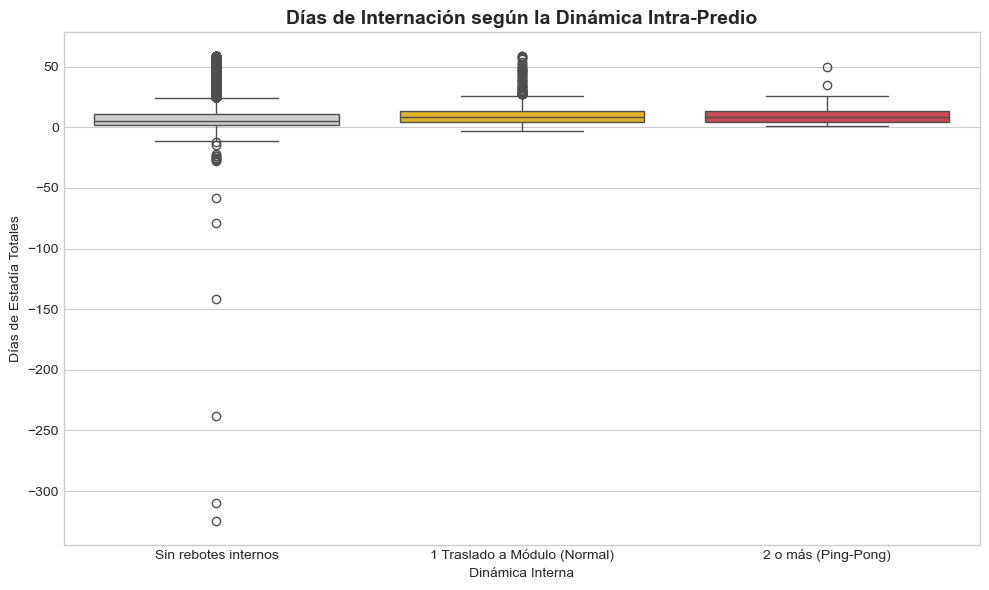

In [20]:
# 16. DESARMANDO EL MISTERIO: Anatomía del paciente "Ping-Pong" (Sin usar ARM)
# =============================================================================

# 1. Rescatamos los datos clínicos desde la historia en bruto (df_base)
# Buscamos si pasó por críticas en algún momento y su riesgo clínico inicial
df_clinico_pingpong = df_base.groupby('paciente_id').agg({
    'paso_criticas': lambda x: 'Si' if any(str(v).lower() in ['si', 'sí', 'true'] for v in x) else 'No',
    'riesgo_clinico': 'first'
}).reset_index()

# Cruzamos estos datos clínicos con nuestra tabla de análisis
df_pacientes_pingpong = df_pacientes_pingpong.merge(df_clinico_pingpong, on='paciente_id', how='left')

# (Nota: Omitimos recalcular 'dias_estadia_total' porque ya existe en este DataFrame 
# gracias a nuestra nueva arquitectura relacional).

# 2. Analizamos el paso por Terapia Intensiva (Críticas) y Riesgo Clínico
columnas_analisis = ['paso_criticas', 'riesgo_clinico']

print("➤ PERFIL CLÍNICO DEL PACIENTE SEGÚN SU DINÁMICA DE TRASLADOS:")
for col in columnas_analisis:
    print(f"\n--- Distribución de '{col.upper()}' ---")
    cruce = pd.crosstab(
        df_pacientes_pingpong['tipo_pingpong'], 
        df_pacientes_pingpong[col], 
        normalize='index' # Porcentaje por fila
    ) * 100
    display(cruce.round(1).style.format("{:.1f}%"))

# 3. Analizamos el Tiempo y Destino
print("\n➤ RESULTADO LOGÍSTICO (Días de internación y Destino final):")
metricas_logisticas = df_pacientes_pingpong.groupby('tipo_pingpong').agg(
    total_pacientes=('paciente_id', 'count'),
    promedio_dias_estadia=('dias_estadia_total', 'mean'),
    mediana_dias_estadia=('dias_estadia_total', 'median'),
    # ACÁ CORREGIDO: Buscamos 'alta' porque unificamos los nombres antes
    alta_domiciliaria_pct=('motivo_fin_caso', lambda x: (x == 'alta').mean() * 100)
).round(1)

display(metricas_logisticas)

# 4. Gráfico para hacerlo visual en tu presentación
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_pacientes_pingpong[df_pacientes_pingpong['dias_estadia_total'] < 60], # Cortamos outliers de más de 2 meses para el dibujo
            x='tipo_pingpong', y='dias_estadia_total', 
            palette=['#cccccc', '#ffc107', '#dc3545'], ax=ax)

ax.set_title("Días de Internación según la Dinámica Intra-Predio", fontsize=14, fontweight='bold')
ax.set_xlabel("Dinámica Interna")
ax.set_ylabel("Días de Estadía Totales")
plt.tight_layout()
plt.show()

In [21]:
# NUEVA CELDA: RESUMEN DE INGRESOS Y TRASLADOS POR ETAPA Y GLOBAL
# =============================================================================

resultados_resumen = []

# 1. Calcular por cada etapa definida en PERIODOS
for titulo, inicio, fin in PERIODOS:
    # Contar ingresos en el periodo
    mask_ingresos = df_base['fecha_ingreso'].between(inicio, fin)
    ingresos_etapa = df_base[mask_ingresos].shape[0]
    
    # Contar traslados en el periodo (usamos fecha_egreso que es cuando ocurre el salto)
    mask_traslados = df_aristas_traslados['fecha_egreso'].between(inicio, fin)
    traslados_etapa = df_aristas_traslados[mask_traslados].shape[0]
    
    resultados_resumen.append({
        'Etapa / Periodo': titulo,
        'Ingresos': ingresos_etapa,
        'Traslados': traslados_etapa
    })

df_resumen = pd.DataFrame(resultados_resumen)

# 2. Calcular los totales Globales de toda la base (sin filtro de fecha)
ingresos_globales = df_base.shape[0]
traslados_globales = df_aristas_traslados.shape[0]

# 3. Anexar la fila de Totales Globales al DataFrame
fila_total = pd.DataFrame([{
    'Etapa / Periodo': 'GLOBAL (Histórico Total)',
    'Ingresos': ingresos_globales,
    'Traslados': traslados_globales
}])

df_resumen_final = pd.concat([df_resumen, fila_total], ignore_index=True)

# 4. Calcular el Porcentaje de Derivación (Opcional pero muy útil para el análisis)
df_resumen_final['% de Traslado'] = (df_resumen_final['Traslados'] / df_resumen_final['Ingresos'] * 100).round(1).astype(str) + '%'

# Imprimir resultados
print("="*70)
print("📊 CONTEO DIRECTO: INGRESOS Y TRASLADOS POR ETAPA")
print("="*70)
display(df_resumen_final)

📊 CONTEO DIRECTO: INGRESOS Y TRASLADOS POR ETAPA


,Etapa / Periodo,Ingresos,Traslados,% de Traslado
0,Primera Ola,5944,482,8.1%
1,Intermedia,2839,218,7.7%
2,Segunda Ola,6193,526,8.5%
3,Post-vacunación,11347,509,4.5%
4,GLOBAL (Histórico Total),29697,1736,5.8%


In [22]:
df_base

,hospital_id,hospital_origen,paciente_id,fecha_ingreso,estado_ingreso,tipo_ingreso,estado_ultimo,tipo_ultimo,sexo,edad,...,paso_generales,fecha_ingreso_red,fecha_egreso_red,motivos_historial,motivo_fin_caso,hospital_destino,fecha_ingreso_destino,estado_destino,tipo_destino,dias_traslado
0,147,UPA 17 - QU,1,2020-05-01 12:11:27,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,36,...,no,2020-05-01 12:11:27,2020-06-08 12:11:28,"[traslado-otro, alta-domiciliaria, alta-domici...",alta,Oñativia,2020-05-19 12:11:20,ocupadas_covid,intermedias,-77.0
1,8,Oñativia,1,2020-05-19 12:11:20,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,44,...,no,2020-05-01 12:11:27,2020-06-08 12:11:28,"[traslado-otro, alta-domiciliaria, alta-domici...",alta,UPA 10 - BE,2020-06-07 12:11:28,ocupadas_otros,intermedias,2.0
2,148,UPA 10 - BE,1,2020-06-07 12:11:28,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,NaN,...,no,2020-05-01 12:11:27,2020-06-08 12:11:28,"[traslado-otro, alta-domiciliaria, alta-domici...",alta,NaN,NaT,NaN,NaN,NaN
3,147,UPA 17 - QU,2,2020-04-06 12:11:27,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,59,...,no,2020-04-06 12:11:27,2020-06-11 12:11:19,"[alta-domiciliaria, traslado-extra-sanitario]",alta hotel,Oñativia,2020-05-29 12:11:19,ocupadas_covid,intermedias,-26.0
4,8,Oñativia,2,2020-05-29 12:11:19,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,28,...,no,2020-04-06 12:11:27,2020-06-11 12:11:19,"[alta-domiciliaria, traslado-extra-sanitario]",alta hotel,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29692,10,Evita Pueblo,ZZ94,2021-07-30 12:11:23,ocupadas_otros,criticas,ocupadas_otros,criticas,femenino,53,...,no,2021-07-30 12:11:23,2021-07-30 12:11:23,[traslado-otro],hospital externo,NaN,NaT,NaN,NaN,NaN
29693,5,Iriarte,ZZ98,2022-02-08 12:11:13,ocupadas_otros,criticas,ocupadas_otros,generales,masculino,38,...,si,2022-02-08 12:11:13,NaT,[nan],otro/desconocido,NaN,NaT,NaN,NaN,NaN
29694,145,UPA 5 - AB,ZZ99,2022-07-05 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,66,...,no,2022-07-05 12:11:25,2022-07-07 12:11:21,"[traslado-hospital-de-la-red, traslado-otro]",hospital externo,Módulo Hospitalario 9 - AB,2022-07-06 12:11:21,ocupadas_otros,criticas,0.0
29695,9,Módulo Hospitalario 9 - AB,ZZ99,2022-07-06 12:11:21,ocupadas_otros,criticas,ocupadas_otros,criticas,femenino,66,...,no,2022-07-05 12:11:25,2022-07-07 12:11:21,"[traslado-hospital-de-la-red, traslado-otro]",hospital externo,NaN,NaT,NaN,NaN,NaN
